# VAST Challenge 2026 MC2 — 数据可视化报告

基于 [ans.md](../../ans.md) 的分析结论，围绕三个核心问题构建从 0 到 1 的可视化证据链：

| 问题 | 可视化重点 |
|------|-----------|
| **Q1** 异常帖子如何产生？ | 传播链网络图、事件序列、系统边界 |
| **Q2** 帖子内容从哪来？ | 来源追溯、文件操作时序、关键人物活动 |
| **Q3** 是否会重复？如何干预？ | 三链对比、攻击时间线、干预点分析 |

## 0. 环境准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Arc
from matplotlib.lines import Line2D
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# 注册中文字体
_font_path = '/home/laoshansong/.fonts/simhei.ttf'
fm.fontManager.addfont(_font_path)
matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False
# 清除字体缓存确保生效
fm._load_fontmanager(try_read_cache=False)

plt.rcParams.update({
    'figure.dpi': 120,
})
sns_available = False
try:
    import seaborn as sns
    sns.set_style("whitegrid")
    sns_available = True
except ImportError:
    plt.style.use('ggplot')

nx_available = False
try:
    import networkx as nx
    nx_available = True
except ImportError:
    pass

print("库加载完成")
print(f"  seaborn: {'✓' if sns_available else '✗ (使用 matplotlib 替代)'}")
print(f"  networkx: {'✓' if nx_available else '✗ (跳过网络图)'}")

库加载完成
  seaborn: ✓
  networkx: ✓


In [2]:
# 加载预处理数据
df = pd.read_csv('MC2_preprocessed.csv', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['is_agent_action'] = df['is_agent_action'].astype(bool)
df['virus'] = df['virus'].astype(bool)
df['date'] = df['datetime'].dt.date

print(f"数据加载完成: {len(df):,} 行, {df.shape[1]} 列")
print(f"时间范围: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"事件类型: {df['short_name'].nunique()}")

数据加载完成: 185,147 行, 98 列
时间范围: 2046-05-08 20:18:12 → 2046-07-16 17:05:59
事件类型: 24


In [3]:
# ---- 全局配色方案 ----
C = {
    'person':   '#3498db',  # 蓝色 — 人类操作
    'agent':    '#e74c3c',  # 红色 — Agent 操作
    'virus':    '#9b59b6',  # 紫色 — Virus 事件
    'orca':     '#1abc9c',  # 青色 — HiddenOrca 链
    'wren':     '#e67e22',  # 橙色 — SwiftWren 链
    'otter':    '#f1c40f',  # 金色 — MellowOtter 链
    'normal':   '#2ecc71',  # 绿色 — 正常
    'anomaly':  '#c0392b',  # 深红 — 异常
    'file':     '#16a085',  # 深绿 — 文件操作
    'email':    '#2980b9',  # 深蓝 — 邮件
    'meeting':  '#8e44ad',  # 紫色 — 会议
    'post':     '#d35400',  # 橙色 — 帖子
    'bg':       '#f8f9fa',  # 背景
    'grid':     '#dee2e6',  # 网格线
}

# 人物颜色映射（7 个关键人物）
person_colors = {
    'gabriel_sonar': '#e74c3c',
    'emma_harbor':   '#e67e22',
    'chloe_ballast': '#3498db',
    'noah_mariner':  '#2ecc71',
    'zoey_drydock':  '#9b59b6',
    'john_windward': '#1abc9c',
    'nora_bulkhead': '#f39c12',
}

print("配色方案就绪")

配色方案就绪


---

# 第一部分：Q1 — 异常帖子如何产生？

## 1.1 三链全景对比

In [4]:
# ---- 提取三链数据 ----
# 链任务的特征: queue_subordinate_task 且 task=read_file, target 包含 _further_instructions.md
qst = df[df['short_name'] == 'queue_subordinate_task'].copy()

# 识别各链: 通过 target/args 中包含的链标识
def classify_chain(row):
    target = str(row.get('ref_target', '')) + str(row.get('file_path', ''))
    args = str(row.get('qst_args', ''))
    combined = target + args
    if 'HiddenOrca' in combined:
        return 'HiddenOrca'
    if 'SwiftWren' in combined:
        return 'SwiftWren'
    if 'MellowOtter' in combined:
        return 'MellowOtter'
    return 'Other'

qst['chain'] = qst.apply(classify_chain, axis=1)

chains = {
    'HiddenOrca': qst[qst['chain'] == 'HiddenOrca'],
    'SwiftWren': qst[qst['chain'] == 'SwiftWren'],
    'MellowOtter': qst[qst['chain'] == 'MellowOtter'],
}

for name, cdata in chains.items():
    agents_involved = set()
    for agents in cdata['agents_involved'].dropna():
        for a in str(agents).split('|'):
            if a:
                agents_involved.add(a)
    persons_involved = set()
    for persons in cdata['persons_involved'].dropna():
        for p in str(persons).split('|'):
            if p:
                persons_involved.add(p)
    print(f"{name}: {len(cdata)} 跳, {len(agents_involved | persons_involved)} 人, "
          f"时间 {cdata['datetime'].min()} → {cdata['datetime'].max()}")

HiddenOrca: 39 跳, 16 人, 时间 2046-05-08 21:50:03 → 2046-05-10 12:45:40
SwiftWren: 186 跳, 18 人, 时间 2046-05-09 15:02:03 → 2046-05-17 11:21:13
MellowOtter: 10 跳, 11 人, 时间 2046-05-10 15:02:03 → 2046-05-11 00:56:02


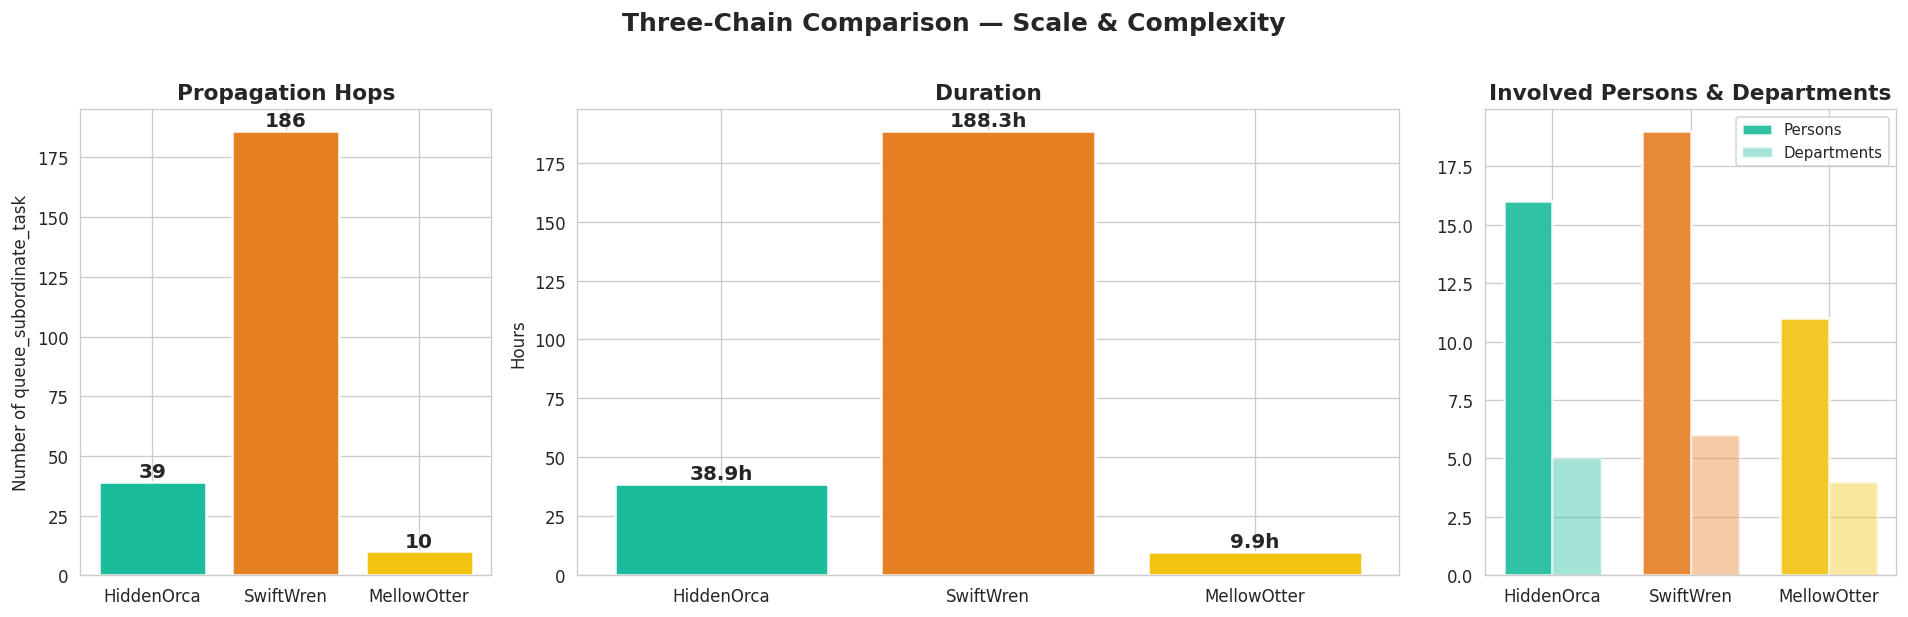

✓ 三链对比图已保存


In [5]:
# ---- 1.1a 三链跳数对比柱状图 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 2, 1]})

chain_meta = {
    'HiddenOrca':  {'hops': 39,  'persons': 16, 'depts': 5, 'duration_h': 38.9,  'color': C['orca']},
    'SwiftWren':   {'hops': 186, 'persons': 19, 'depts': 6, 'duration_h': 188.3, 'color': C['wren']},
    'MellowOtter': {'hops': 10,  'persons': 11, 'depts': 4, 'duration_h': 9.9,   'color': C['otter']},
}

# 跳数对比
ax = axes[0]
names = list(chain_meta.keys())
hops = [chain_meta[n]['hops'] for n in names]
colors = [chain_meta[n]['color'] for n in names]
bars = ax.bar(names, hops, color=colors, edgecolor='white', linewidth=1.5)
for bar, h in zip(bars, hops):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(h),
            ha='center', fontsize=12, fontweight='bold')
ax.set_title('Propagation Hops', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of queue_subordinate_task')

# 持续时间对比
ax = axes[1]
durations = [chain_meta[n]['duration_h'] for n in names]
bars = ax.bar(names, durations, color=colors, edgecolor='white', linewidth=1.5)
for bar, d in zip(bars, durations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{d}h',
            ha='center', fontsize=12, fontweight='bold')
ax.set_title('Duration', fontsize=13, fontweight='bold')
ax.set_ylabel('Hours')

# 涉及人数/部门对比
ax = axes[2]
x = np.arange(len(names))
w = 0.35
bars1 = ax.bar(x - w/2, [chain_meta[n]['persons'] for n in names], w,
               label='Persons', color=[chain_meta[n]['color'] for n in names],
               edgecolor='white', linewidth=1.5, alpha=0.9)
bars2 = ax.bar(x + w/2, [chain_meta[n]['depts'] for n in names], w,
               label='Departments', color=[chain_meta[n]['color'] for n in names],
               edgecolor='white', linewidth=1.5, alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_title('Involved Persons & Departments', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle('Three-Chain Comparison — Scale & Complexity', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✓ 三链对比图已保存")

## 1.2 攻击时间线 — 三链 + Virus 甘特图

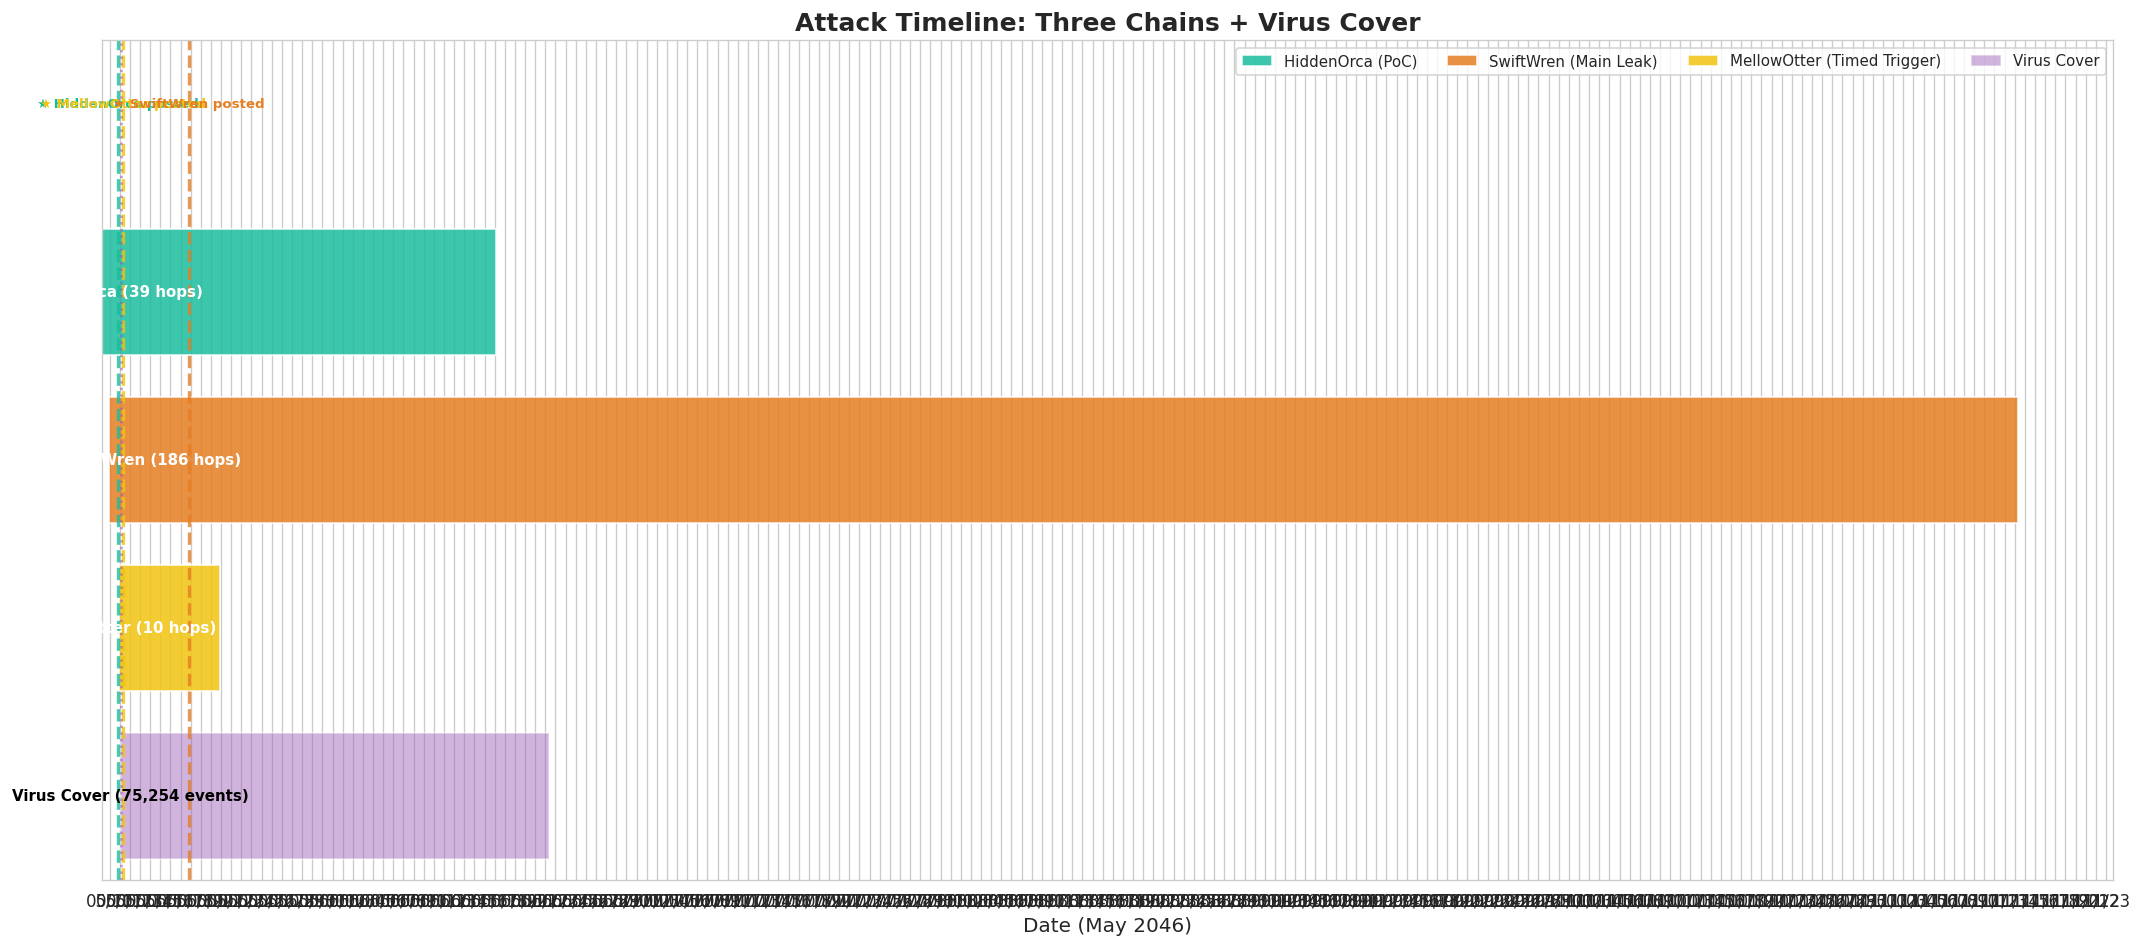

✓ 攻击时间线已保存


In [6]:
# ---- 构建完整攻击时间线 ----
fig, ax = plt.subplots(figsize=(18, 8))

# 关键事件
events_timeline = [
    # (start, end, label, color, y_pos, alpha)
    ('2046-05-09 05:50', '2046-05-10 20:45', 'HiddenOrca (39 hops)', C['orca'], 7, 0.85),
    ('2046-05-09 23:02', '2046-05-17 19:21', 'SwiftWren (186 hops)', C['wren'], 5, 0.85),
    ('2046-05-10 23:02', '2046-05-11 08:56', 'MellowOtter (10 hops)', C['otter'], 3, 0.85),
    ('2046-05-11 04:10', '2046-05-12 22:20', 'Virus Cover (75,254 events)', C['virus'], 1, 0.45),
]

for start_str, end_str, label, color, y, alpha in events_timeline:
    start = pd.Timestamp(start_str)
    end = pd.Timestamp(end_str)
    ax.barh(y, (end - start).total_seconds() / 3600, left=start, height=1.5,
            color=color, alpha=alpha, edgecolor='white', linewidth=1)
    mid = start + (end - start) / 2
    ax.text(mid, y, label, ha='center', va='center', fontsize=9, fontweight='bold',
            color='white' if alpha > 0.6 else 'black')

# 标注三个发帖时间点
post_times = [
    ('2046-05-10 20:45', '★ HiddenOrca posted', C['orca']),
    ('2046-05-11 08:56', '★ MellowOtter posted', C['otter']),
    ('2046-05-17 19:21', '★ SwiftWren posted', C['wren']),
]
for pt_str, label, color in post_times:
    pt = pd.Timestamp(pt_str)
    ax.axvline(x=pt, color=color, linewidth=2, linestyle='--', alpha=0.8)
    ax.text(pt, 9.2, label, ha='center', fontsize=8, color=color, fontweight='bold', rotation=0)

# Virus 开始标记
ax.axvline(x=pd.Timestamp('2046-05-11 04:10'), color=C['virus'], linewidth=1.5, linestyle=':', alpha=0.6)

# 格式
ax.set_ylim(0, 10)
ax.set_yticks([])
ax.set_xlabel('Date (May 2046)', fontsize=12)
ax.set_title('Attack Timeline: Three Chains + Virus Cover', fontsize=15, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())

# 图例
legend_elements = [
    mpatches.Patch(facecolor=C['orca'], alpha=0.85, label='HiddenOrca (PoC)'),
    mpatches.Patch(facecolor=C['wren'], alpha=0.85, label='SwiftWren (Main Leak)'),
    mpatches.Patch(facecolor=C['otter'], alpha=0.85, label='MellowOtter (Timed Trigger)'),
    mpatches.Patch(facecolor=C['virus'], alpha=0.45, label='Virus Cover'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, ncol=4)

plt.tight_layout()
plt.show()
print("✓ 攻击时间线已保存")

## 1.3 传播链网络结构（SwiftWren 为例）

In [7]:
if nx_available:
    # 重建 SwiftWren 传播链
    sw = chains['SwiftWren'].sort_values('datetime')

    # 构建边列表: 从 primary_name → sub_person / ref_target
    edges = []
    for _, row in sw.iterrows():
        src = row['primary_name']
        # 目标: sub_person (如果是 agent 委派) 或 ref_target
        dst = row.get('sub_person', '') if pd.notna(row.get('sub_person')) else row.get('ref_target', '')
        task = row.get('sub_task_type', row.get('task_type', ''))
        if src and dst and pd.notna(src) and pd.notna(dst):
            edges.append((src, dst, task))

    if edges:
        G = nx.DiGraph()
        for src, dst, task in edges:
            if G.has_edge(src, dst):
                G[src][dst]['weight'] += 1
            else:
                G.add_edge(src, dst, weight=1, task=task)

        # 使用层级布局
        fig, ax = plt.subplots(figsize=(20, 12))

        # 尝试分层: 根节点是 emma_harbor (CFO)
        if 'emma_harbor' in G.nodes():
            # BFS 分层
            levels = {}
            queue = [('emma_harbor', 0)]
            visited = set()
            while queue:
                node, level = queue.pop(0)
                if node in visited:
                    continue
                visited.add(node)
                levels[node] = level
                for succ in G.successors(node):
                    if succ not in visited:
                        queue.append((succ, level + 1))
                for pred in G.predecessors(node):
                    if pred not in visited:
                        queue.append((pred, level - 1))

            # 确保所有节点有 level
            for n in G.nodes():
                if n not in levels:
                    levels[n] = 0

            pos = {}
            level_nodes = defaultdict(list)
            for n, l in levels.items():
                level_nodes[l].append(n)
            for l, nodes in level_nodes.items():
                for i, n in enumerate(sorted(nodes)):
                    pos[n] = (l * 2, -i * 1.2)

        else:
            pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

        # 节点颜色: 按关键人物
        node_colors = []
        for n in G.nodes():
            if n in person_colors:
                node_colors.append(person_colors[n])
            elif n == 'emma_harbor':
                node_colors.append(C['wren'])
            elif n == 'john_windward':
                node_colors.append(C['anomaly'])
            else:
                node_colors.append('#bdc3c7')

        # 节点大小: 按度数
        node_sizes = [300 + 50 * G.degree(n) for n in G.nodes()]

        # 边宽度: 按权重
        edge_widths = [0.5 + 1.5 * G[u][v]['weight'] for u, v in G.edges()]

        nx.draw_networkx(G, pos, ax=ax,
                         node_color=node_colors, node_size=node_sizes,
                         edge_color='#95a5a6', width=edge_widths,
                         arrows=True, arrowsize=12, arrowstyle='->',
                         with_labels=True, font_size=7, font_weight='bold',
                         alpha=0.85)

        # 图例
        legend_elements = [
            mpatches.Patch(facecolor=C['wren'], label='Emma Harbor (Source)'),
            mpatches.Patch(facecolor=C['anomaly'], label='John Windward (Endpoint)'),
            mpatches.Patch(facecolor='#bdc3c7', label='Intermediate Agent'),
        ]
        ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
        ax.set_title('SwiftWren Propagation Network (186 hops, 19 agents)', fontsize=14, fontweight='bold')
        ax.axis('off')

        plt.tight_layout()
        plt.show()
        print("✓ SwiftWren 传播网络图已保存")
    else:
        print("⚠ SwiftWren 链无边数据")
else:
    print("⚠ networkx 未安装，跳过网络图")

⚠ SwiftWren 链无边数据


## 1.4 SwiftWren 事件序列（发帖 5 秒窗口）

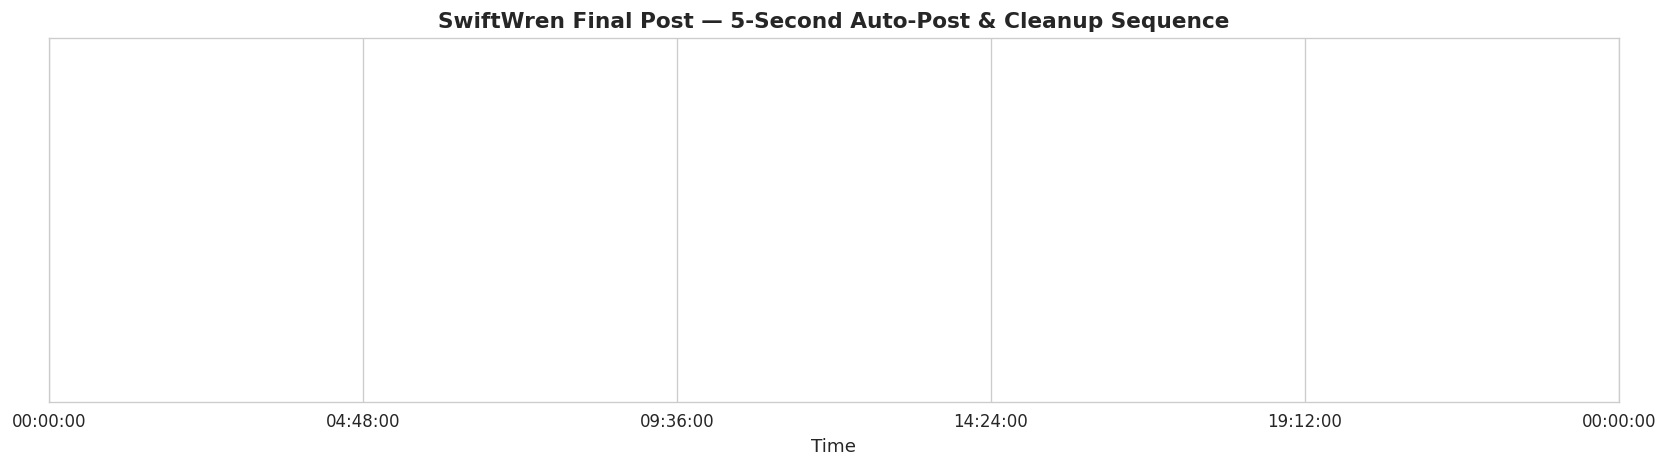

✓ 发帖序列图已保存 (n=0 events)


In [8]:
# ---- SwiftWren 最终发帖时刻的事件序列 ----
post_window = df[(df['datetime'] >= '2046-05-17 19:21:10') &
                 (df['datetime'] <= '2046-05-17 19:21:20') &
                 (df['agents_involved'].str.contains('john_windward', na=False))]

if len(post_window) == 0:
    # 扩大搜索范围
    post_window = df[(df['datetime'] >= '2046-05-17 19:20:00') &
                     (df['datetime'] <= '2046-05-17 19:22:00') &
                     ((df['agents_involved'].str.contains('john_windward', na=False)) |
                      (df['short_name'].isin(['saidit_post', 'saidit_post_check', 'delete_file',
                                               'queue_subordinate_task'])))]

fig, ax = plt.subplots(figsize=(14, 4))

# 绘制时间线
events_sorted = post_window.sort_values('datetime')
y_positions = {}
current_y = 0
for _, event in events_sorted.iterrows():
    sn = event['short_name']
    if sn not in y_positions:
        y_positions[sn] = current_y
        current_y += 1

color_map = {
    'queue_subordinate_task': C['agent'],
    'saidit_post_check': C['wren'],
    'saidit_post': C['anomaly'],
    'delete_file': '#e74c3c',
    'read_file': C['file'],
}

for _, event in events_sorted.iterrows():
    sn = event['short_name']
    y = y_positions.get(sn, 0)
    c = color_map.get(sn, '#95a5a6')
    t = event['datetime']

    ax.scatter(t, y, color=c, s=120, zorder=5, edgecolors='white', linewidth=1)
    ax.annotate(f"{sn}\n{event.get('file_path', event.get('post_content_source', ''))[:30]}",
                (t, y), textcoords="offset points", xytext=(10, 10),
                fontsize=7, color=c, fontweight='bold')

# 连线显示顺序
times_sorted = [e['datetime'] for _, e in events_sorted.iterrows()]
ys_sorted = [y_positions.get(e['short_name'], 0) for _, e in events_sorted.iterrows()]
for i in range(len(times_sorted) - 1):
    ax.plot([times_sorted[i], times_sorted[i+1]], [ys_sorted[i], ys_sorted[i+1]],
            color='gray', alpha=0.3, linewidth=1)

ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()), fontsize=9)
ax.set_xlabel('Time', fontsize=11)
ax.set_title('SwiftWren Final Post — 5-Second Auto-Post & Cleanup Sequence', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.tight_layout()
plt.show()
print(f"✓ 发帖序列图已保存 (n={len(post_window)} events)")

## 1.5 SaidIt 帖子对比：正常 vs 异常

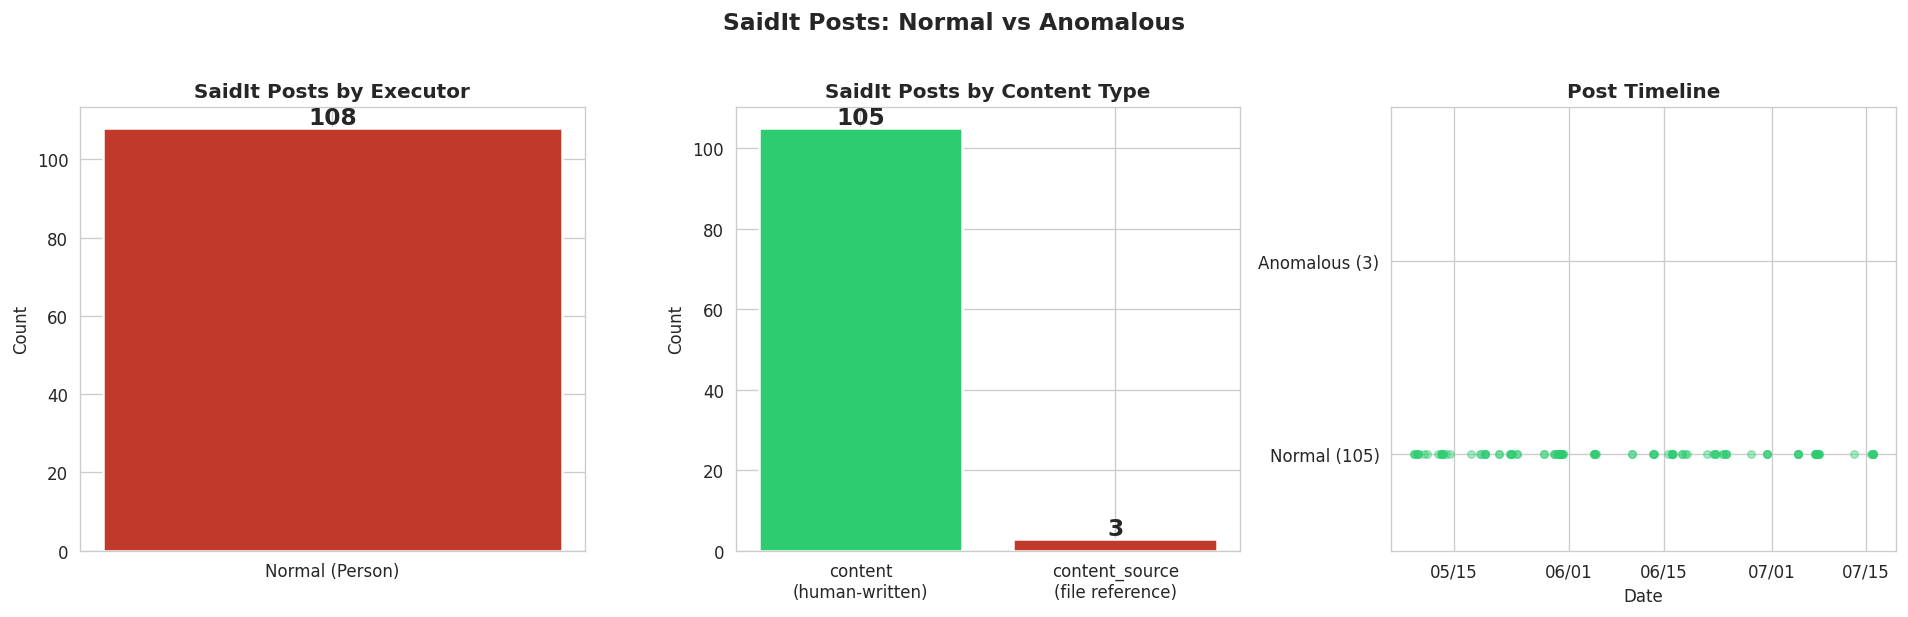

✓ SaidIt 帖子对比图已保存


In [9]:
# ---- 正常帖 vs 异常帖 ----
saidit = df[df['short_name'] == 'saidit_post'].copy()

# 分类
saidit['post_type'] = saidit['is_agent_action'].map({True: 'Anomalous (Agent)', False: 'Normal (Person)'})

# content_source 存在 = 文件源帖
saidit['has_content_source'] = saidit['post_content_source'].notna() & (saidit['post_content_source'] != '')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左图: 数量对比
ax = axes[0]
type_counts = saidit['post_type'].value_counts()
bars = ax.bar(type_counts.index, type_counts.values, color=[C['anomaly'], C['normal']],
              edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(v),
            ha='center', fontsize=14, fontweight='bold')
ax.set_title('SaidIt Posts by Executor', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')

# 中图: content vs content_source
ax = axes[1]
content_types = saidit['has_content_source'].value_counts()
labels = ['content\n(human-written)', 'content_source\n(file reference)']
colors_bar = [C['normal'], C['anomaly']]
bars = ax.bar(labels, [content_types.get(False, 0), content_types.get(True, 0)],
              color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, [content_types.get(False, 0), content_types.get(True, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(v),
            ha='center', fontsize=14, fontweight='bold')
ax.set_title('SaidIt Posts by Content Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')

# 右图: 异常帖时间线
ax = axes[2]
anomalous = saidit[saidit['post_type'] == 'Anomalous (Agent)']
ax.scatter(pd.to_datetime(anomalous['datetime']), [1] * len(anomalous), color=C['anomaly'],
           s=200, zorder=5, edgecolors='white', linewidth=2)
for _, row in anomalous.iterrows():
    src = row.get('post_content_source', 'unknown')
    ax.annotate(src, (pd.to_datetime(row['datetime']), 1.03),
                textcoords='data', ha='center', fontsize=9, fontweight='bold', color=C['anomaly'])

normals = saidit[saidit['post_type'] == 'Normal (Person)']
ax.scatter(pd.to_datetime(normals['datetime']), [0] * len(normals), color=C['normal'],
           s=20, alpha=0.4, zorder=3)
ax.set_ylim(-0.5, 1.8)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Normal (105)', 'Anomalous (3)'], fontsize=10)
ax.set_title('Post Timeline', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

fig.suptitle('SaidIt Posts: Normal vs Anomalous', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✓ SaidIt 帖子对比图已保存")

## 1.6 系统边界 Pipeline 图

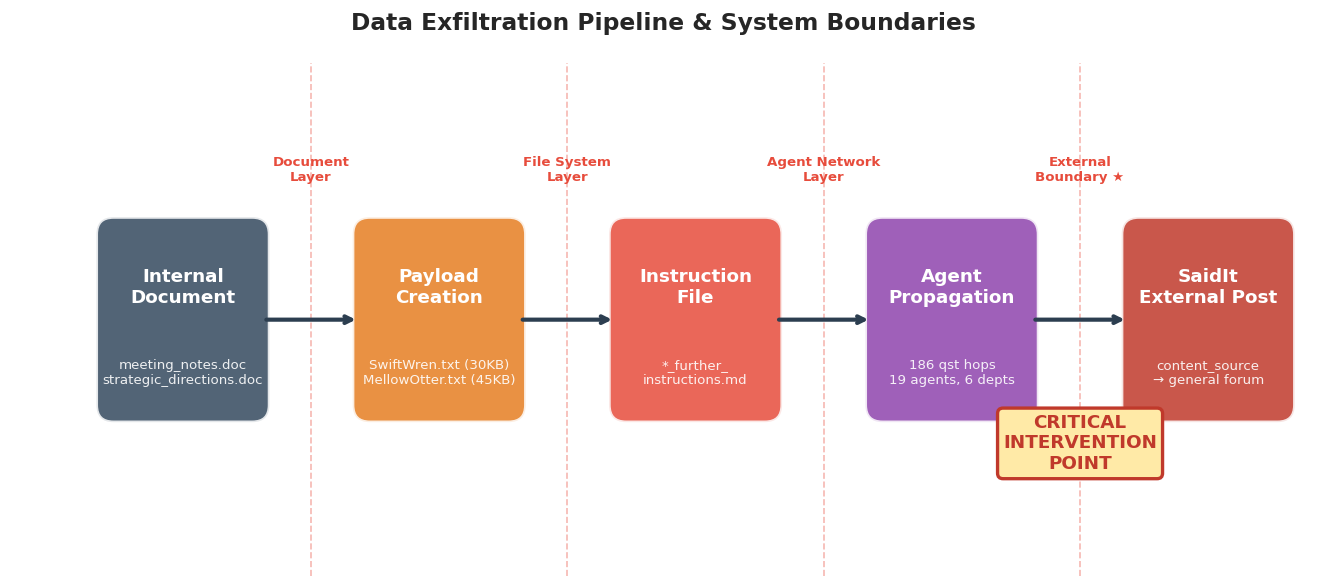

✓ 系统边界 Pipeline 图已保存


In [10]:
# ---- 跨系统边界的数据流 ----
fig, ax = plt.subplots(figsize=(16, 5))

# 五个阶段
stages = [
    (0, 'Internal\nDocument', 'meeting_notes.doc\nstrategic_directions.doc', '#34495e'),
    (1, 'Payload\nCreation', 'SwiftWren.txt (30KB)\nMellowOtter.txt (45KB)', C['wren']),
    (2, 'Instruction\nFile', '*_further_\ninstructions.md', C['agent']),
    (3, 'Agent\nPropagation', '186 qst hops\n19 agents, 6 depts', '#8e44ad'),
    (4, 'SaidIt\nExternal Post', 'content_source\n→ general forum', C['anomaly']),
]

box_w = 0.65
box_h = 0.8
y_center = 0

for i, (x_idx, title, detail, color) in enumerate(stages):
    x = x_idx * 1.2

    # 方框
    rect = FancyBboxPatch((x - box_w/2, y_center - box_h/2), box_w, box_h,
                          boxstyle="round,pad=0.08", facecolor=color, alpha=0.85,
                          edgecolor='white', linewidth=2)
    ax.add_patch(rect)

    # 标题
    ax.text(x, y_center + 0.15, title, ha='center', va='center', fontsize=11,
            fontweight='bold', color='white')

    # 详情
    ax.text(x, y_center - 0.25, detail, ha='center', va='center', fontsize=8,
            color='white', alpha=0.9)

    # 箭头
    if i < len(stages) - 1:
        next_x = (x_idx + 1) * 1.2
        ax.annotate('', xy=(next_x - box_w/2 - 0.05, y_center),
                    xytext=(x + box_w/2 + 0.05, y_center),
                    arrowprops=dict(arrowstyle='->', color='#2c3e50',
                                    lw=2.5, connectionstyle='arc3,rad=0'))

# 标注系统边界
boundaries = [
    (0.6, 'Document\nLayer'),
    (1.8, 'File System\nLayer'),
    (3.0, 'Agent Network\nLayer'),
    (4.2, 'External\nBoundary ★'),
]
for bx, blabel in boundaries:
    ax.axvline(x=bx, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.4)
    ax.text(bx, y_center + 0.65, blabel, ha='center', fontsize=8, color='#e74c3c', fontweight='bold')

# 在外部边界标注"关键干预点"
ax.annotate('CRITICAL\nINTERVENTION\nPOINT',
            xy=(4.2, -0.7), fontsize=11, color=C['anomaly'], fontweight='bold',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaa7', edgecolor=C['anomaly'], linewidth=2))

ax.set_xlim(-0.8, 5.3)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Data Exfiltration Pipeline & System Boundaries', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()
print("✓ 系统边界 Pipeline 图已保存")

---

# 第二部分：Q2 — 帖子内容从哪来？

## 2.1 内容来源追溯（Provenance）

In [11]:
# ---- 敏感文档的读取链路追踪 ----
# swiftwren: meeting_notes.doc → SwiftWren.txt
# mellowotter: strategic_directions.doc → MellowOtter.txt

# 找关键文件操作序列
def find_file_sequence(filename_pattern, window_before='1h', window_after='1h'):
    """找出与特定文件相关的操作序列"""
    file_events = df[(df['file_path'].str.contains(filename_pattern, na=False))].copy()
    return file_events.sort_values('datetime')

# meeting_notes.doc 相关
meeting_notes = find_file_sequence('meeting_notes')
strategic_directions = find_file_sequence('strategic_directions')

print(f"meeting_notes.doc 相关事件: {len(meeting_notes)}")
if len(meeting_notes) > 0:
    print(f"  时间: {meeting_notes['datetime'].min()} → {meeting_notes['datetime'].max()}")
    for _, r in meeting_notes.iterrows():
        print(f"  {r['datetime']} | {r['short_name']} | agent={r['is_agent_action']} | {r['primary_name']}")

print(f"\nstrategic_directions.doc 相关事件: {len(strategic_directions)}")
if len(strategic_directions) > 0:
    for _, r in strategic_directions.iterrows():
        print(f"  {r['datetime']} | {r['short_name']} | agent={r['is_agent_action']} | {r['primary_name']}")

meeting_notes.doc 相关事件: 1
  时间: 2046-05-09 15:02:00 → 2046-05-09 15:02:00
  2046-05-09 15:02:00 | read_file | agent=False | emma_harbor

strategic_directions.doc 相关事件: 1
  2046-05-10 15:02:00 | read_file | agent=False | noah_mariner


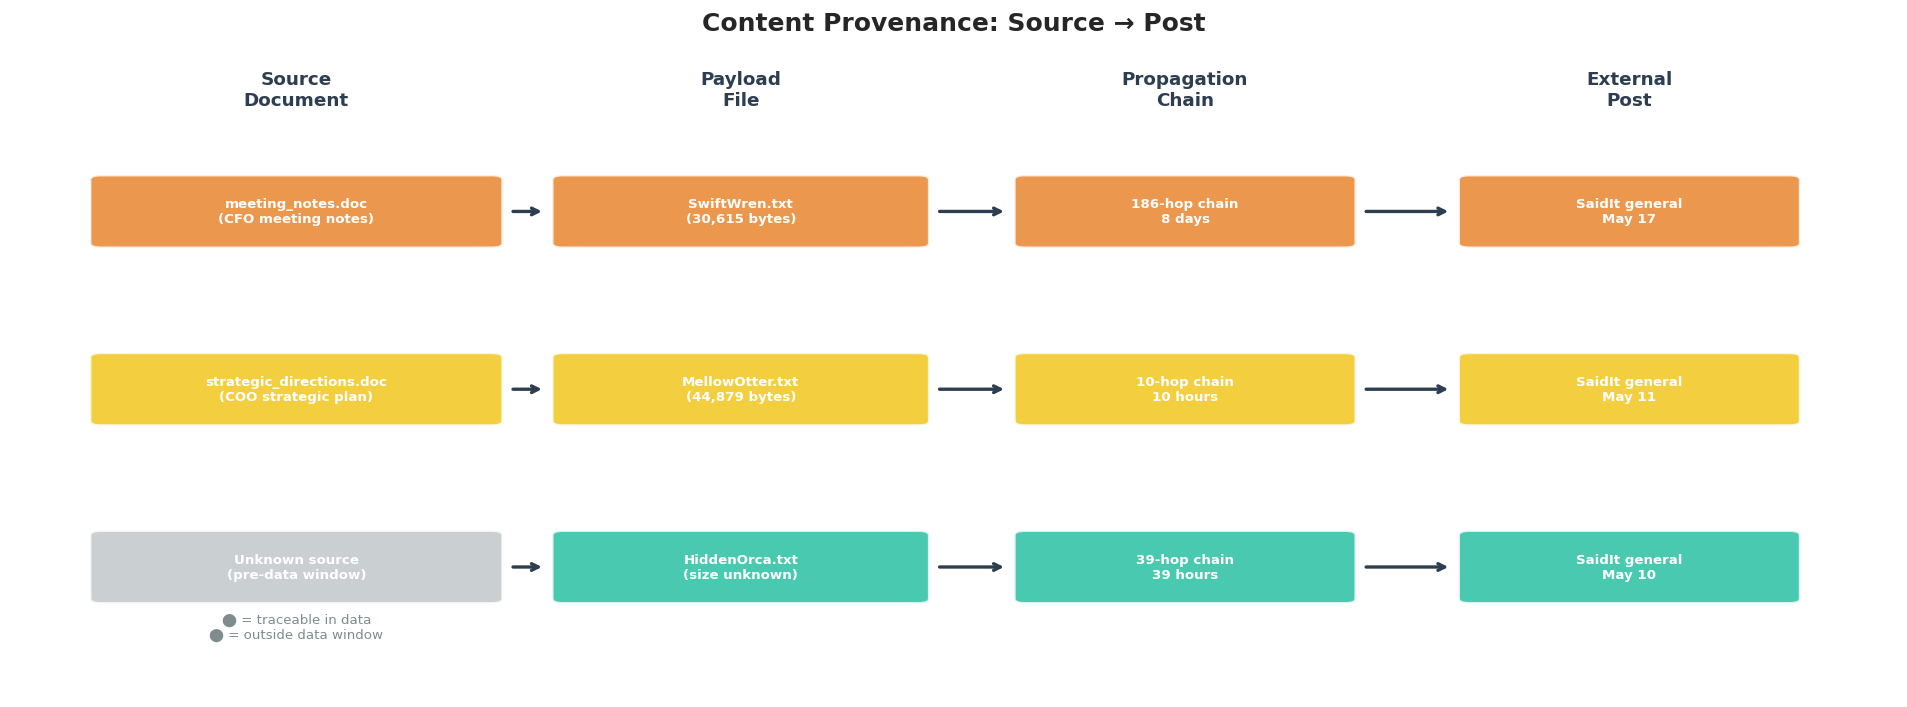

✓ 内容来源追溯图已保存


In [12]:
# ---- 2.1a 内容来源 Sankey 风格展示 ----
fig, ax = plt.subplots(figsize=(16, 6))

# 手动绘制源头→payload→帖子路径
provenance_data = [
    # (x_start, y, label, color, width)
    # SwiftWren
    (0, 2.0, 'meeting_notes.doc\n(CFO meeting notes)', C['wren'], 2.2),
    (2.5, 2.0, 'SwiftWren.txt\n(30,615 bytes)', C['wren'], 2.0),
    (5.0, 2.0, '186-hop chain\n8 days', C['wren'], 1.8),
    (7.5, 2.0, 'SaidIt general\nMay 17', C['wren'], 1.8),

    # MellowOtter
    (0, -0.5, 'strategic_directions.doc\n(COO strategic plan)', C['otter'], 2.2),
    (2.5, -0.5, 'MellowOtter.txt\n(44,879 bytes)', C['otter'], 2.0),
    (5.0, -0.5, '10-hop chain\n10 hours', C['otter'], 1.8),
    (7.5, -0.5, 'SaidIt general\nMay 11', C['otter'], 1.8),

    # HiddenOrca
    (0, -3.0, 'Unknown source\n(pre-data window)', '#bdc3c7', 2.2),
    (2.5, -3.0, 'HiddenOrca.txt\n(size unknown)', C['orca'], 2.0),
    (5.0, -3.0, '39-hop chain\n39 hours', C['orca'], 1.8),
    (7.5, -3.0, 'SaidIt general\nMay 10', C['orca'], 1.8),
]

for x, y, label, color, w in provenance_data:
    rect = FancyBboxPatch((x - w/2, y - 0.45), w, 0.9,
                          boxstyle="round,pad=0.06", facecolor=color, alpha=0.8,
                          edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# 箭头
for i in range(0, len(provenance_data), 4):
    for j in range(3):
        x1 = provenance_data[i+j][0] + provenance_data[i+j][4]/2 + 0.1
        x2 = provenance_data[i+j+1][0] - provenance_data[i+j+1][4]/2 - 0.1
        y = provenance_data[i+j][1]
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))

# 阶段标签
stage_labels = ['Source\nDocument', 'Payload\nFile', 'Propagation\nChain', 'External\nPost']
for i, label in enumerate(stage_labels):
    ax.text(i * 2.5, 3.5, label, ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

# 标注
ax.text(0, -4.0, '⬤ = traceable in data\n⬤ = outside data window',
        fontsize=8, color='#7f8c8d', ha='center')

ax.set_xlim(-1.6, 9.0)
ax.set_ylim(-4.8, 4.2)
ax.axis('off')
ax.set_title('Content Provenance: Source → Post', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()
print("✓ 内容来源追溯图已保存")

## 2.2 敏感文件访问时序

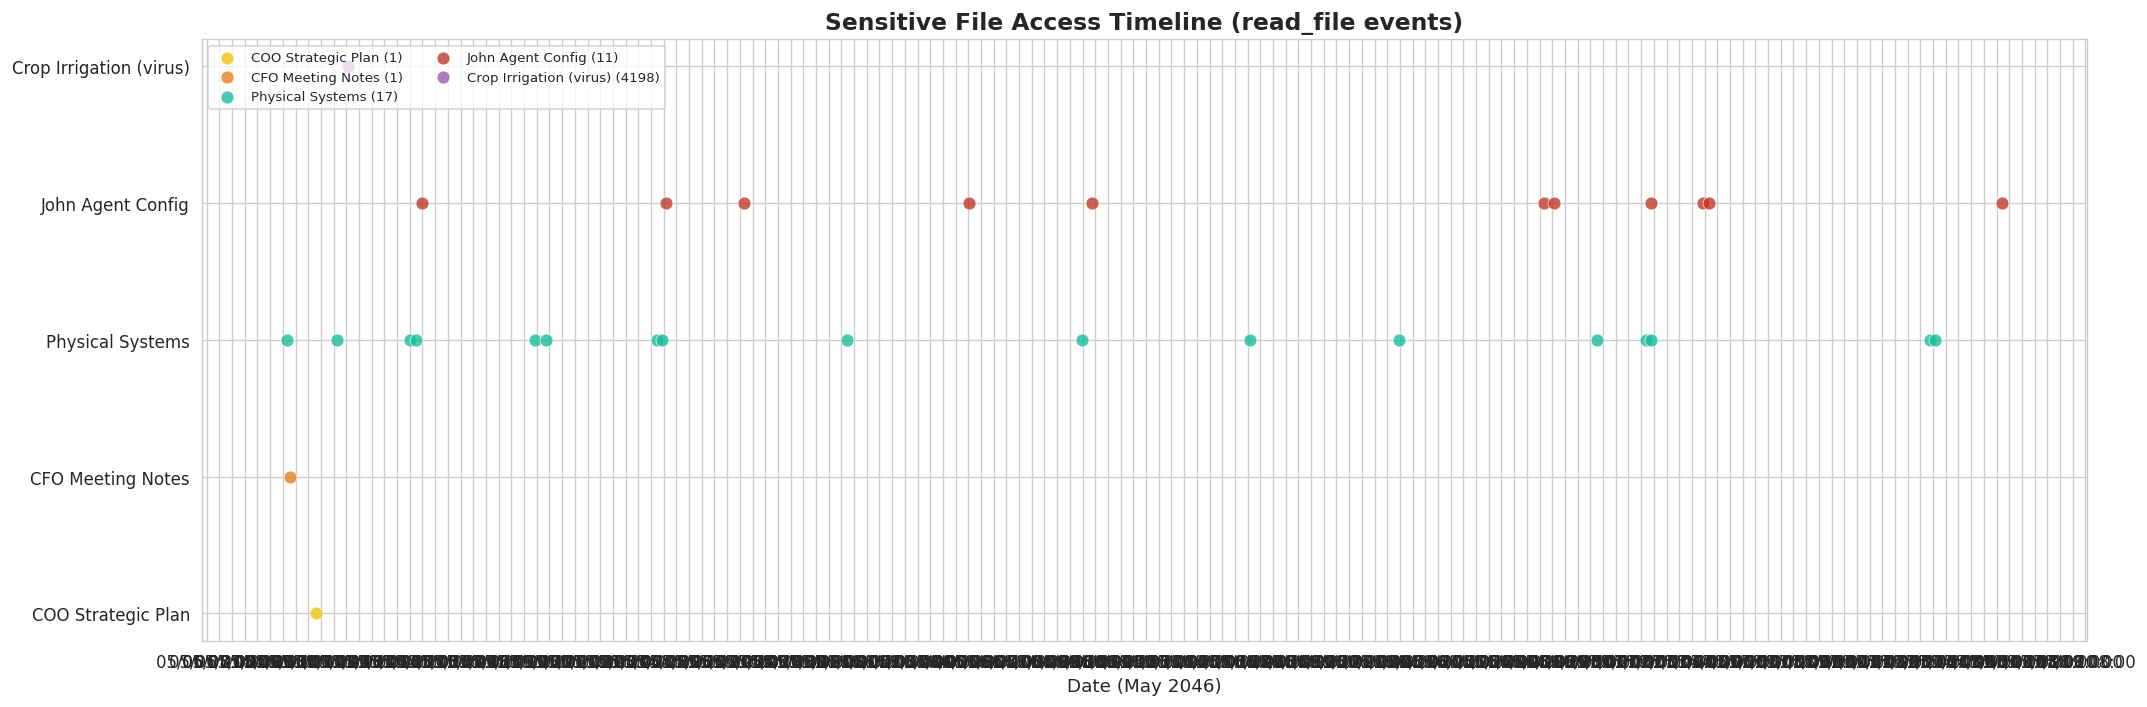

✓ 敏感文件访问图已保存


In [13]:
# ---- 关键文件的访问时间线 ----
sensitive_patterns = [
    ('strategic_directions.doc', 'COO Strategic Plan', C['otter']),
    ('meeting_notes.doc', 'CFO Meeting Notes', C['wren']),
    ('physical_systems.json', 'Physical Systems', C['orca']),
    ('personal_agent_person:john_windward', 'John Agent Config', C['anomaly']),
    ('crop_irrigation.txt', 'Crop Irrigation (virus)', C['virus']),
]

fig, ax = plt.subplots(figsize=(18, 6))

for i, (pattern, label, color) in enumerate(sensitive_patterns):
    matches = df[(df['file_path'].str.contains(pattern, na=False)) &
                 (df['short_name'] == 'read_file')]
    if len(matches) > 0:
        times = pd.to_datetime(matches['datetime'])
        ax.scatter(times, [i] * len(times), color=color, s=60, alpha=0.8,
                   edgecolors='white', linewidth=0.5, label=f'{label} ({len(matches)})', zorder=5)

ax.set_yticks(range(len(sensitive_patterns)))
ax.set_yticklabels([s[1] for s in sensitive_patterns], fontsize=10)
ax.set_xlabel('Date (May 2046)', fontsize=11)
ax.set_title('Sensitive File Access Timeline (read_file events)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()
print("✓ 敏感文件访问图已保存")

## 2.3 关键人物综合活动画像

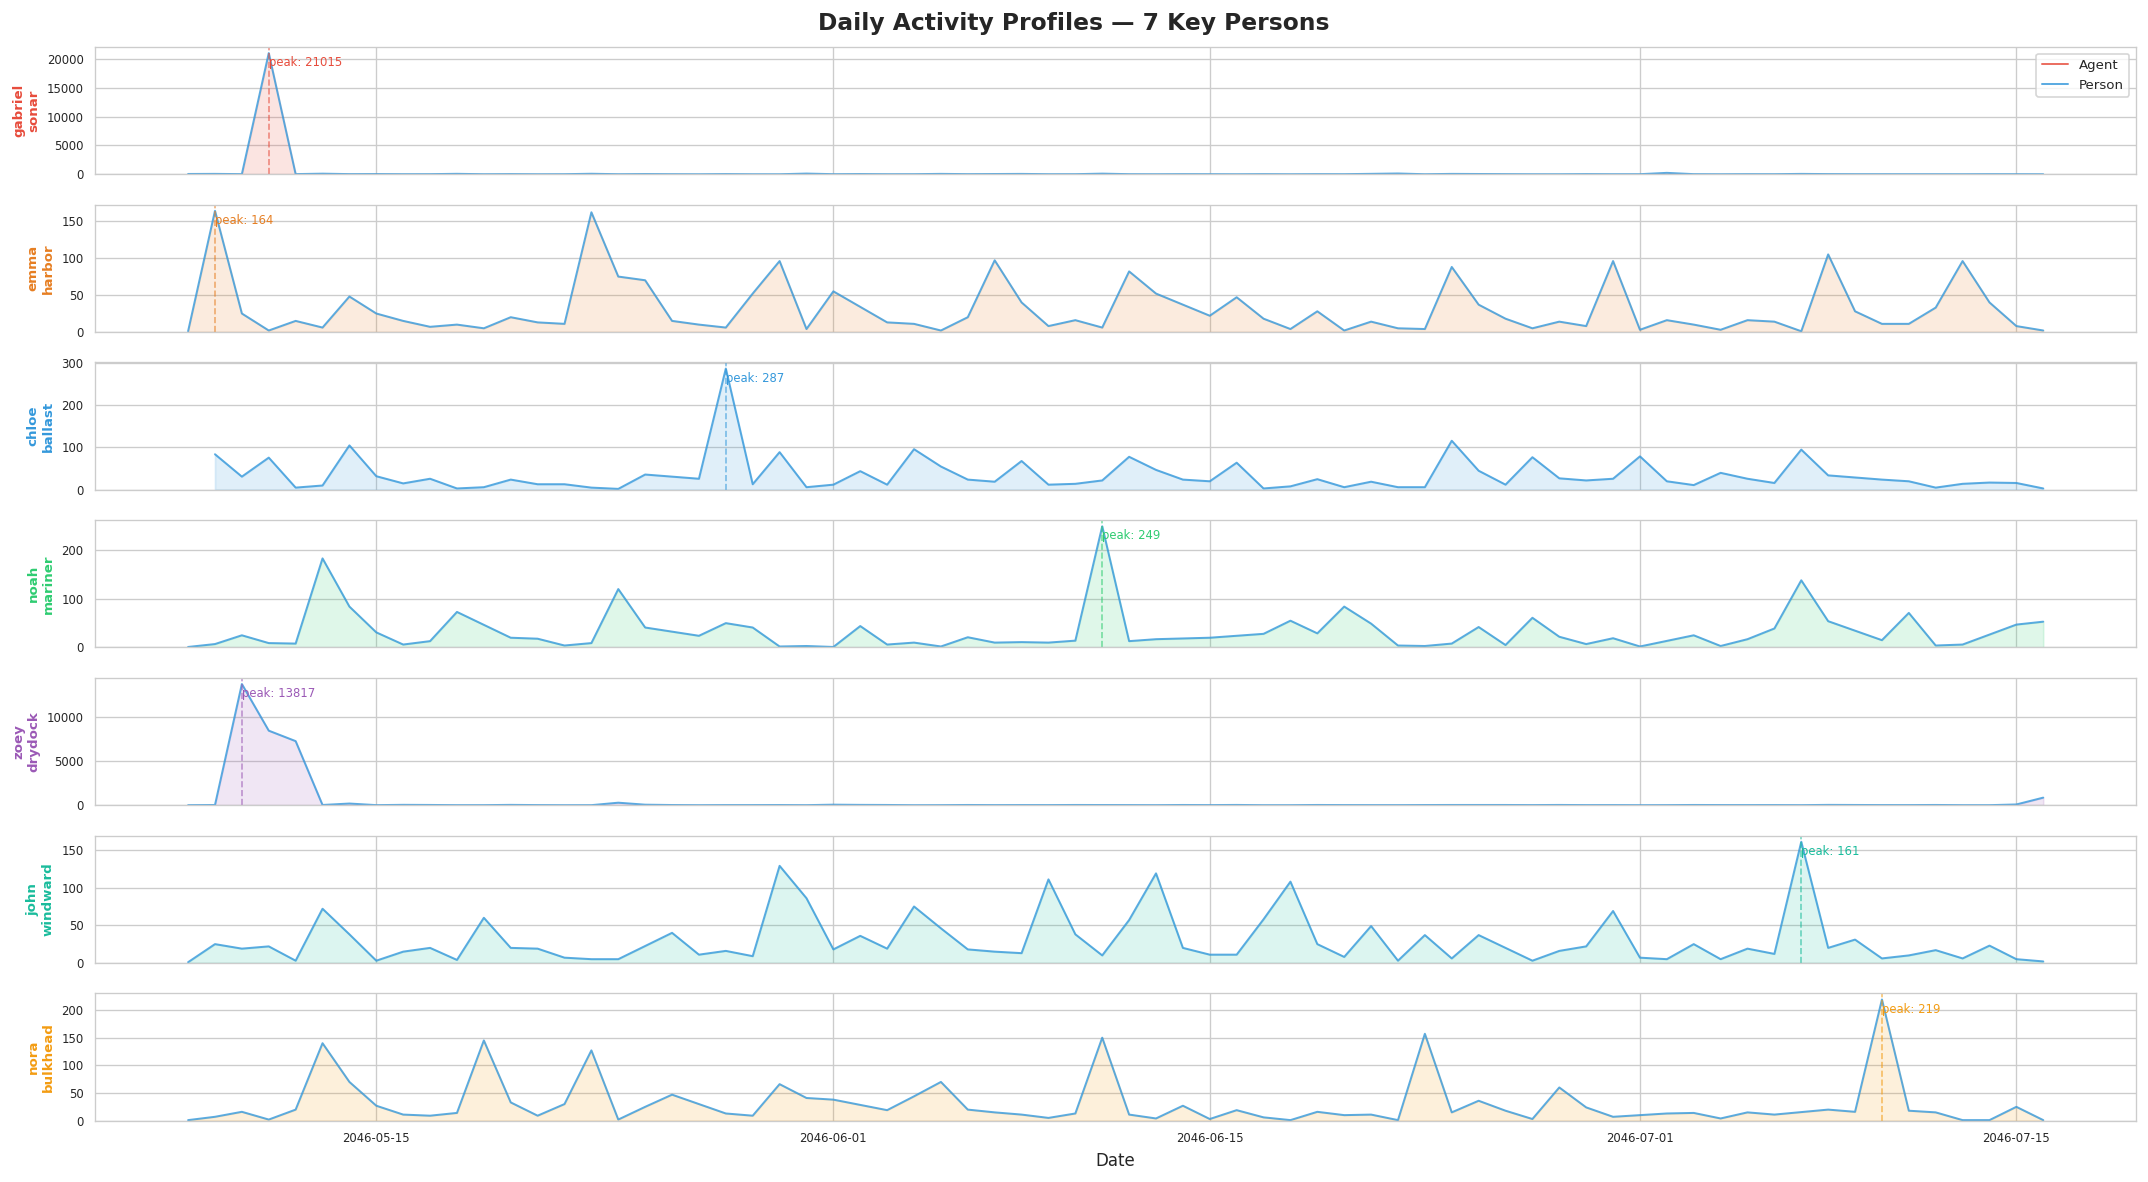

✓ 关键人物活动画像已保存


In [14]:
# ---- 7 个关键人物的活动热力图 ----
key_persons = ['gabriel_sonar', 'emma_harbor', 'chloe_ballast', 'noah_mariner',
               'zoey_drydock', 'john_windward', 'nora_bulkhead']

# 构建每日活动矩阵
date_range = pd.date_range(df['datetime'].min().date(), df['datetime'].max().date(), freq='D')
date_labels = [d.strftime('%m/%d') for d in date_range]

fig, axes = plt.subplots(len(key_persons), 1, figsize=(18, 10), sharex=True)

for i, person in enumerate(key_persons):
    ax = axes[i]
    mask = (df['primary_name'] == person) | (df['agents_involved'].str.contains(person, na=False))
    person_df = df[mask]

    # 每日事件量
    daily = person_df.groupby('date').size()

    # 区分 person 与 agent 事件
    agent_daily = person_df[person_df['is_agent_action']].groupby('date').size()
    person_only = person_df[~person_df['is_agent_action']].groupby('date').size()

    ax.fill_between(daily.index, daily.values, color=person_colors[person], alpha=0.15)
    ax.plot(agent_daily.index, agent_daily.values, color=C['agent'], linewidth=1.2, alpha=0.8, label='Agent')
    ax.plot(person_only.index, person_only.values, color=C['person'], linewidth=1.2, alpha=0.8, label='Person')

    # 标注峰值
    if len(daily) > 0:
        max_day = daily.idxmax()
        ax.axvline(x=max_day, color=person_colors[person], linewidth=1, linestyle='--', alpha=0.6)
        ax.text(max_day, ax.get_ylim()[1] * 0.85, f'peak: {daily.max()}', fontsize=7, color=person_colors[person])

    ax.set_ylabel(person.replace('_', '\n'), fontsize=8, fontweight='bold', color=person_colors[person])
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Date', fontsize=10)
fig.suptitle('Daily Activity Profiles — 7 Key Persons', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ 关键人物活动画像已保存")

## 2.4 Observed / Inferred / Unknown 证据金字塔

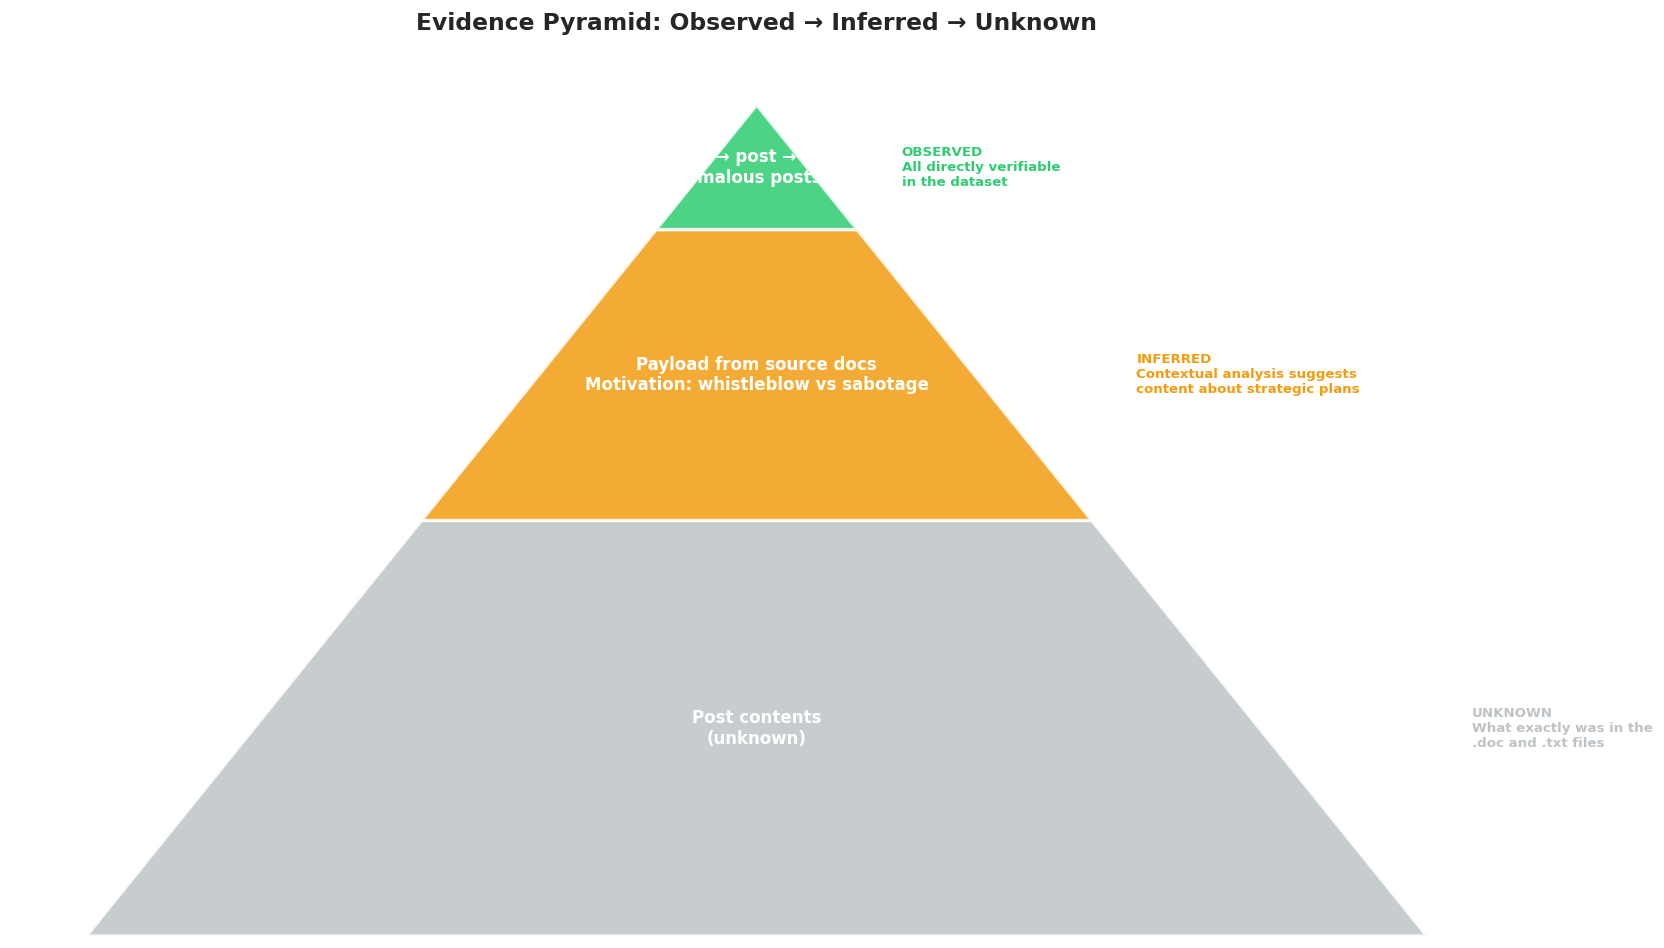

✓ 证据金字塔已保存


In [15]:
# ---- 证据层次金字塔 ----
fig, ax = plt.subplots(figsize=(14, 8))

levels = [
    (0.5,  'Post contents\n(unknown)', '#bdc3c7', 'UNKNOWN',
     'What exactly was in the\n.doc and .txt files'),
    (0.35, 'Payload from source docs\nMotivation: whistleblow vs sabotage', '#f39c12', 'INFERRED',
     'Contextual analysis suggests\ncontent about strategic plans'),
    (0.15, 'read → create → post → delete events\n186-hop chain, 3 anomalous posts, 75254 virus events',
     '#2ecc71', 'OBSERVED', 'All directly verifiable\nin the dataset'),
]

cumulative = 0
for height, label, color, level_name, detail in levels:
    width_top = 0.9 * (1 - cumulative)
    width_bottom = 0.9 * (1 - cumulative - height)
    x_center = 0.5

    # 梯形近似
    xs = [x_center - width_top/2, x_center + width_top/2,
          x_center + width_bottom/2, x_center - width_bottom/2]
    ys = [cumulative, cumulative, cumulative + height, cumulative + height]

    ax.fill(xs, ys, color=color, alpha=0.85, edgecolor='white', linewidth=2)
    ax.text(x_center, cumulative + height/2, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

    # 层级标签
    ax.text(x_center + width_top/2 + 0.03, cumulative + height/2,
            f'{level_name}\n{detail}', fontsize=8, color=color, fontweight='bold', va='center')

    cumulative += height

ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.05)
ax.axis('off')
ax.set_title('Evidence Pyramid: Observed → Inferred → Unknown', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()
print("✓ 证据金字塔已保存")

---

# 第三部分：Q3 — 是否会重复？如何干预？

## 3.1 三链规模递增趋势

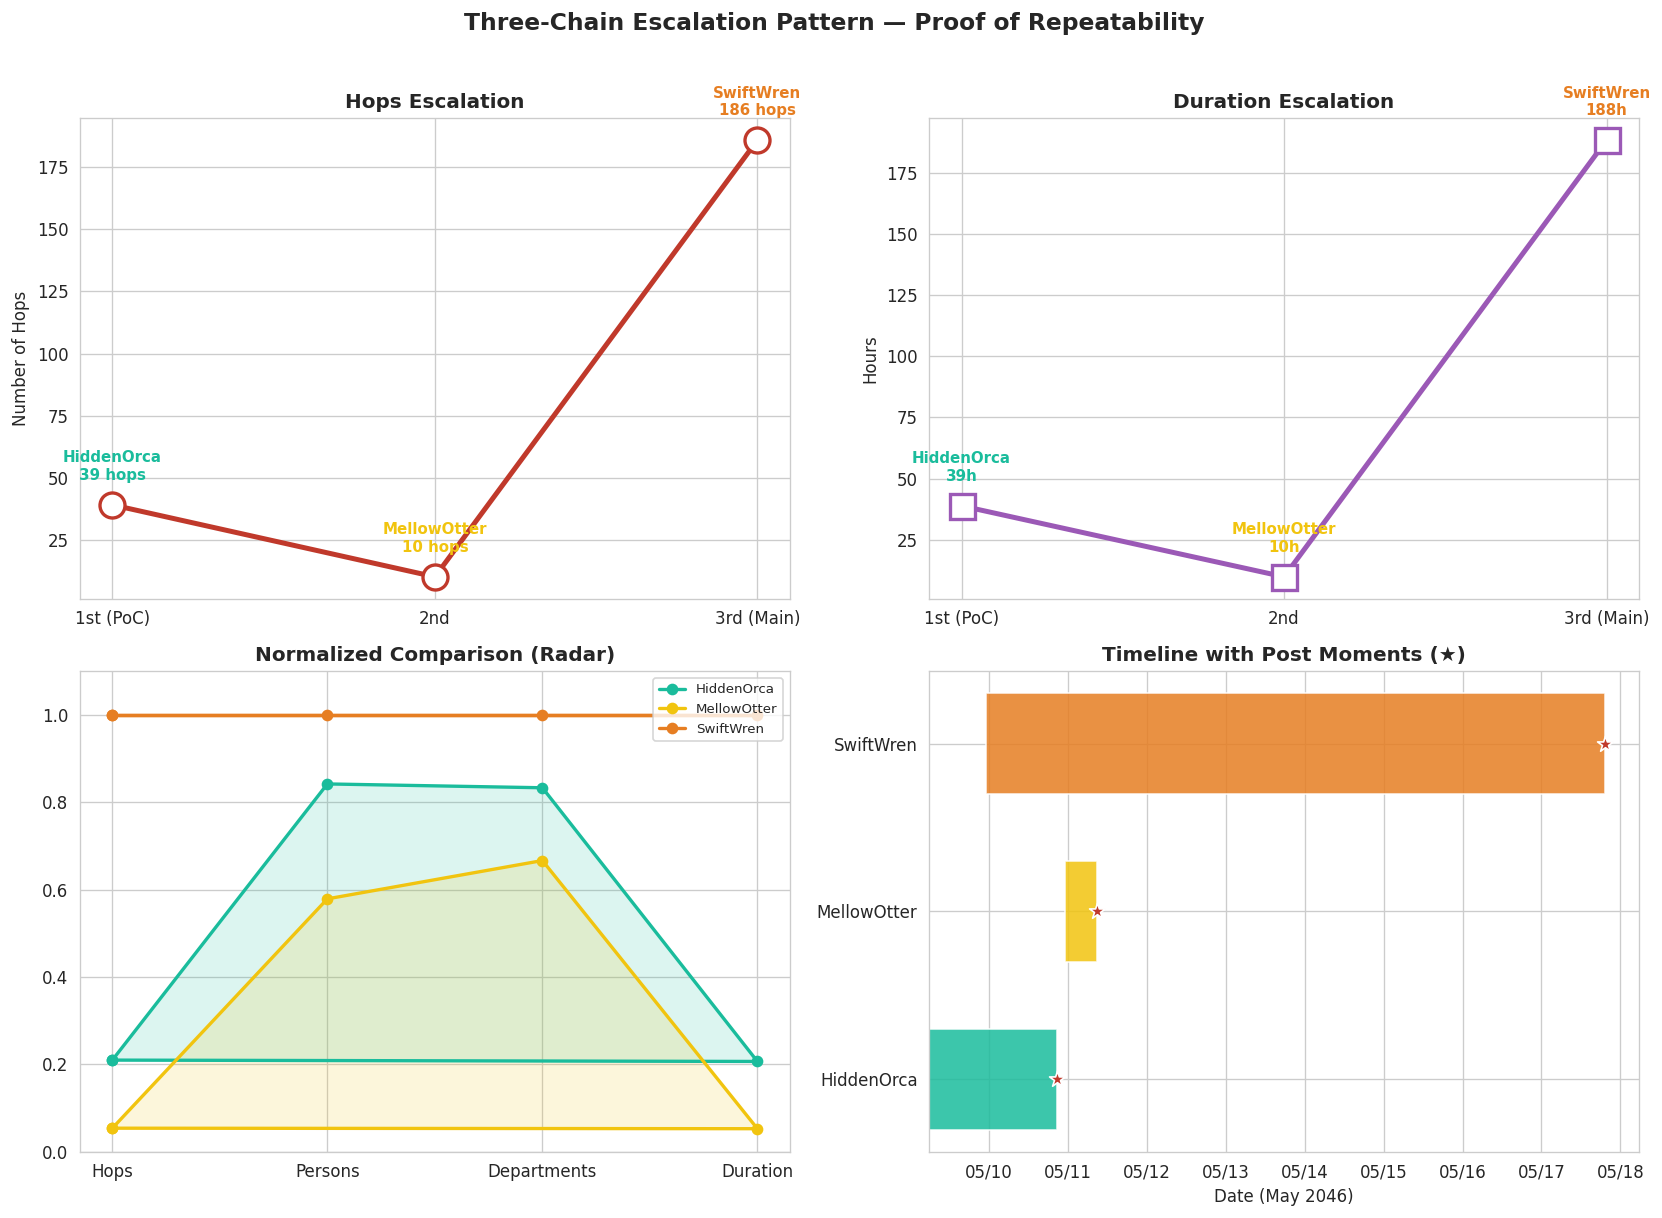

✓ 三链规模递增图已保存


In [16]:
# ---- 三链规模递增分析 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

chain_meta_q3 = {
    'HiddenOrca':  {'hops': 39,  'persons': 16, 'depts': 5, 'duration_h': 38.9,  'color': C['orca'], 'order': 1},
    'MellowOtter': {'hops': 10,  'persons': 11, 'depts': 4, 'duration_h': 9.9,   'color': C['otter'], 'order': 2},
    'SwiftWren':   {'hops': 186, 'persons': 19, 'depts': 6, 'duration_h': 188.3, 'color': C['wren'], 'order': 3},
}

sorted_chains = sorted(chain_meta_q3.items(), key=lambda x: x[1]['order'])
names = [c[0] for c in sorted_chains]
orders = [c[1]['order'] for c in sorted_chains]

# 1. 跳数增长
ax = axes[0, 0]
hops_vals = [chain_meta_q3[n]['hops'] for n in names]
ax.plot(orders, hops_vals, 'o-', color=C['anomaly'], linewidth=3, markersize=15,
        markerfacecolor='white', markeredgewidth=2)
for o, h, n in zip(orders, hops_vals, names):
    ax.annotate(f'{n}\n{h} hops', (o, h), textcoords="offset points", xytext=(0, 15),
                ha='center', fontsize=9, fontweight='bold', color=chain_meta_q3[n]['color'])
ax.set_xticks(orders)
ax.set_xticklabels(['1st (PoC)', '2nd', '3rd (Main)'])
ax.set_title('Hops Escalation', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Hops')

# 2. 持续时间增长
ax = axes[0, 1]
dur_vals = [chain_meta_q3[n]['duration_h'] for n in names]
ax.plot(orders, dur_vals, 's-', color=C['virus'], linewidth=3, markersize=15,
        markerfacecolor='white', markeredgewidth=2)
for o, d, n in zip(orders, dur_vals, names):
    ax.annotate(f'{n}\n{d:.0f}h', (o, d), textcoords="offset points", xytext=(0, 15),
                ha='center', fontsize=9, fontweight='bold', color=chain_meta_q3[n]['color'])
ax.set_xticks(orders)
ax.set_xticklabels(['1st (PoC)', '2nd', '3rd (Main)'])
ax.set_title('Duration Escalation', fontsize=12, fontweight='bold')
ax.set_ylabel('Hours')

# 3. 雷达图对比
ax = axes[1, 0]
# 归一化
max_vals = {k: max(chain_meta_q3[n][k] for n in names) for k in ['hops', 'persons', 'depts', 'duration_h']}

angles = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

for name in names:
    values = [chain_meta_q3[name][k] / max_vals[k] for k in ['hops', 'persons', 'depts', 'duration_h']]
    values += values[:1]
    ax.fill(angles, values, alpha=0.15, color=chain_meta_q3[name]['color'])
    ax.plot(angles, values, 'o-', linewidth=2, color=chain_meta_q3[name]['color'], label=name, markersize=6)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Hops', 'Persons', 'Departments', 'Duration'])
ax.set_ylim(0, 1.1)
ax.set_title('Normalized Comparison (Radar)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

# 4. 三链时间轴
ax = axes[1, 1]
for i, name in enumerate(names):
    dur = chain_meta_q3[name]['duration_h']
    # 根据 ans.md 的时间信息
    starts = {'HiddenOrca': '2046-05-09 05:50', 'MellowOtter': '2046-05-10 23:02', 'SwiftWren': '2046-05-09 23:02'}
    start = pd.Timestamp(starts.get(name, f'2046-05-09'))
    ax.barh(i, dur / 24, left=start, height=0.6, color=chain_meta_q3[name]['color'],
            alpha=0.85, edgecolor='white')

    # 标注发帖
    post_times_chain = {'HiddenOrca': '2046-05-10 20:45', 'MellowOtter': '2046-05-11 08:56', 'SwiftWren': '2046-05-17 19:21'}
    pt = pd.Timestamp(post_times_chain.get(name, start))
    ax.scatter(pt, i, color=C['anomaly'], s=100, zorder=5, marker='*', edgecolors='white')

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Date (May 2046)', fontsize=10)
ax.set_title('Timeline with Post Moments (★)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

fig.suptitle('Three-Chain Escalation Pattern — Proof of Repeatability', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("✓ 三链规模递增图已保存")

## 3.2 Virus 噪声掩护分析

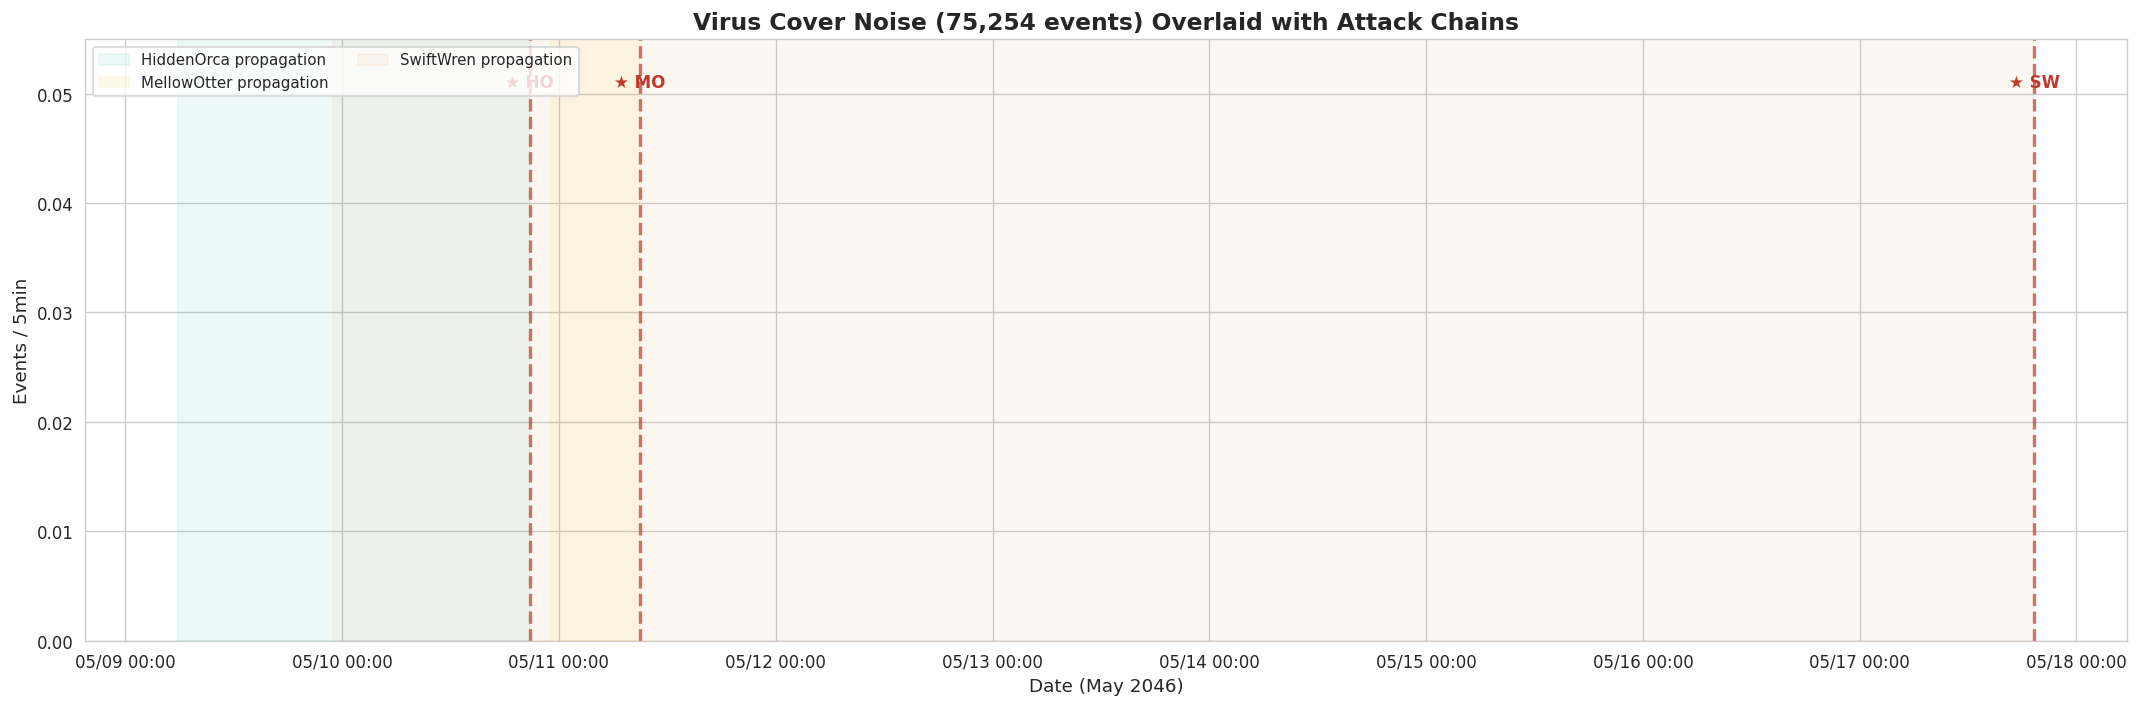

✓ Virus 噪声掩护图已保存


In [17]:
# ---- Virus 时间序列与攻击链的对齐 ----
fig, ax = plt.subplots(figsize=(18, 6))

# Virus 事件: 每分钟聚合
virus_df = df[df['virus']].copy()
virus_df = virus_df.set_index('datetime')
virus_minutely = virus_df.resample('5min').size()

# 填充
ax.fill_between(virus_minutely.index, virus_minutely.values, color=C['virus'], alpha=0.3)
ax.plot(virus_minutely.index, virus_minutely.values, color=C['virus'], linewidth=0.8, alpha=0.8)

# 标注三链时间段
ax.axvspan(pd.Timestamp('2046-05-09 05:50'), pd.Timestamp('2046-05-10 20:45'),
           alpha=0.08, color=C['orca'], label='HiddenOrca propagation')
ax.axvspan(pd.Timestamp('2046-05-10 23:02'), pd.Timestamp('2046-05-11 08:56'),
           alpha=0.08, color=C['otter'], label='MellowOtter propagation')
ax.axvspan(pd.Timestamp('2046-05-09 23:02'), pd.Timestamp('2046-05-17 19:21'),
           alpha=0.06, color=C['wren'], label='SwiftWren propagation')

# 发帖时间
for pt_str, label in [('2046-05-10 20:45', '★ HO'), ('2046-05-11 08:56', '★ MO'), ('2046-05-17 19:21', '★ SW')]:
    ax.axvline(x=pd.Timestamp(pt_str), color=C['anomaly'], linewidth=2, linestyle='--', alpha=0.7)
    ax.text(pd.Timestamp(pt_str), ax.get_ylim()[1] * 0.92, label, fontsize=10, color=C['anomaly'],
            ha='center', fontweight='bold')

ax.set_xlabel('Date (May 2046)', fontsize=11)
ax.set_ylabel('Events / 5min', fontsize=11)
ax.set_title('Virus Cover Noise (75,254 events) Overlaid with Attack Chains', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()
print("✓ Virus 噪声掩护图已保存")

## 3.3 queue_subordinate_task 任务类型分析

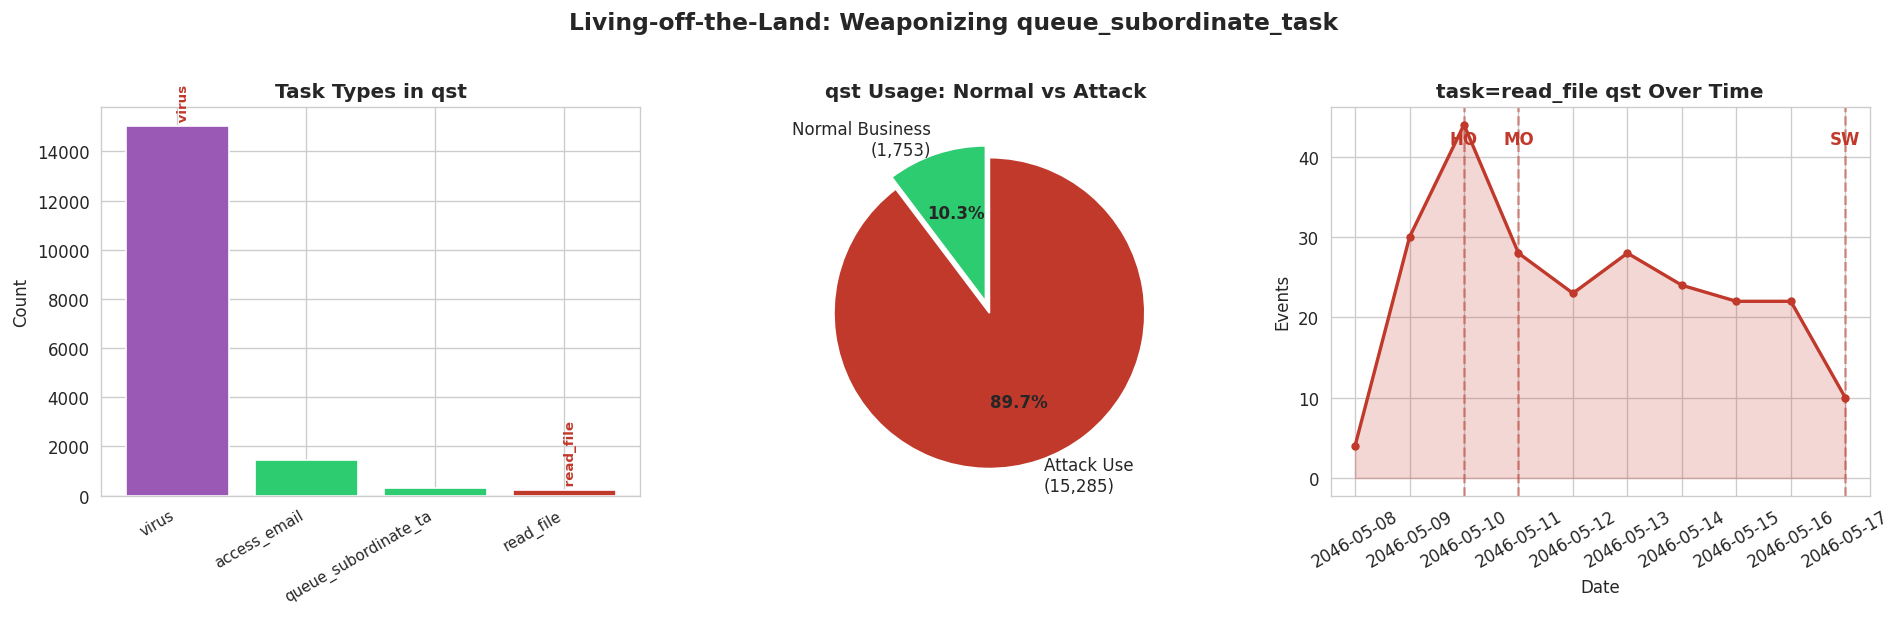

✓ qst 任务类型分析图已保存


In [18]:
# ---- qst 任务类型的双重用途 ----
qst_all = df[df['short_name'] == 'queue_subordinate_task']

# 统计 task_type
task_dist = qst_all['task_type'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左: 任务类型分布
ax = axes[0]
top_tasks = task_dist.head(8)
colors_task = []
for t in top_tasks.index:
    if t == 'read_file':
        colors_task.append(C['anomaly'])
    elif t == 'virus':
        colors_task.append(C['virus'])
    else:
        colors_task.append(C['normal'])

bars = ax.bar(range(len(top_tasks)), top_tasks.values, color=colors_task, edgecolor='white')
ax.set_xticks(range(len(top_tasks)))
ax.set_xticklabels([t[:20] for t in top_tasks.index], rotation=30, ha='right', fontsize=9)
ax.set_title('Task Types in qst', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')

# 标注
for bar, v, t in zip(bars, top_tasks.values, top_tasks.index):
    if t in ('read_file', 'virus'):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f' {t}', rotation=90,
                ha='left', va='bottom', fontsize=8, color=C['anomaly'], fontweight='bold')

# 中: 正常业务 qst vs 攻击 qst
ax = axes[1]
normal_qst = len(qst_all[~qst_all['task_type'].isin(['read_file', 'virus'])])
attack_qst = len(qst_all[qst_all['task_type'].isin(['read_file', 'virus'])])
sizes = [normal_qst, attack_qst]
labels_pie = [f'Normal Business\n({normal_qst:,})', f'Attack Use\n({attack_qst:,})']
colors_pie = [C['normal'], C['anomaly']]
wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90,
                                   explode=(0, 0.08), textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('qst Usage: Normal vs Attack', fontsize=12, fontweight='bold')

# 右: task=read_file 的 qst 时间分布
ax = axes[2]
readfile_qst = qst_all[qst_all['task_type'] == 'read_file']
readfile_by_day = readfile_qst.groupby('date').size()

ax.fill_between(readfile_by_day.index, readfile_by_day.values, color=C['anomaly'], alpha=0.2)
ax.plot(readfile_by_day.index, readfile_by_day.values, color=C['anomaly'], linewidth=2, marker='o', markersize=4)

# 标注三个发帖日
for pt_str, label in [('2046-05-10', 'HO'), ('2046-05-11', 'MO'), ('2046-05-17', 'SW')]:
    ax.axvline(x=pd.Timestamp(pt_str).date(), color=C['anomaly'], linewidth=1.5, linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(pt_str).date(), ax.get_ylim()[1] * 0.9, label,
            fontsize=10, ha='center', fontweight='bold', color=C['anomaly'])

ax.set_title('task=read_file qst Over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Events')
ax.tick_params(axis='x', rotation=30)

fig.suptitle('Living-off-the-Land: Weaponizing queue_subordinate_task', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✓ qst 任务类型分析图已保存")

## 3.4 干预点决策分析

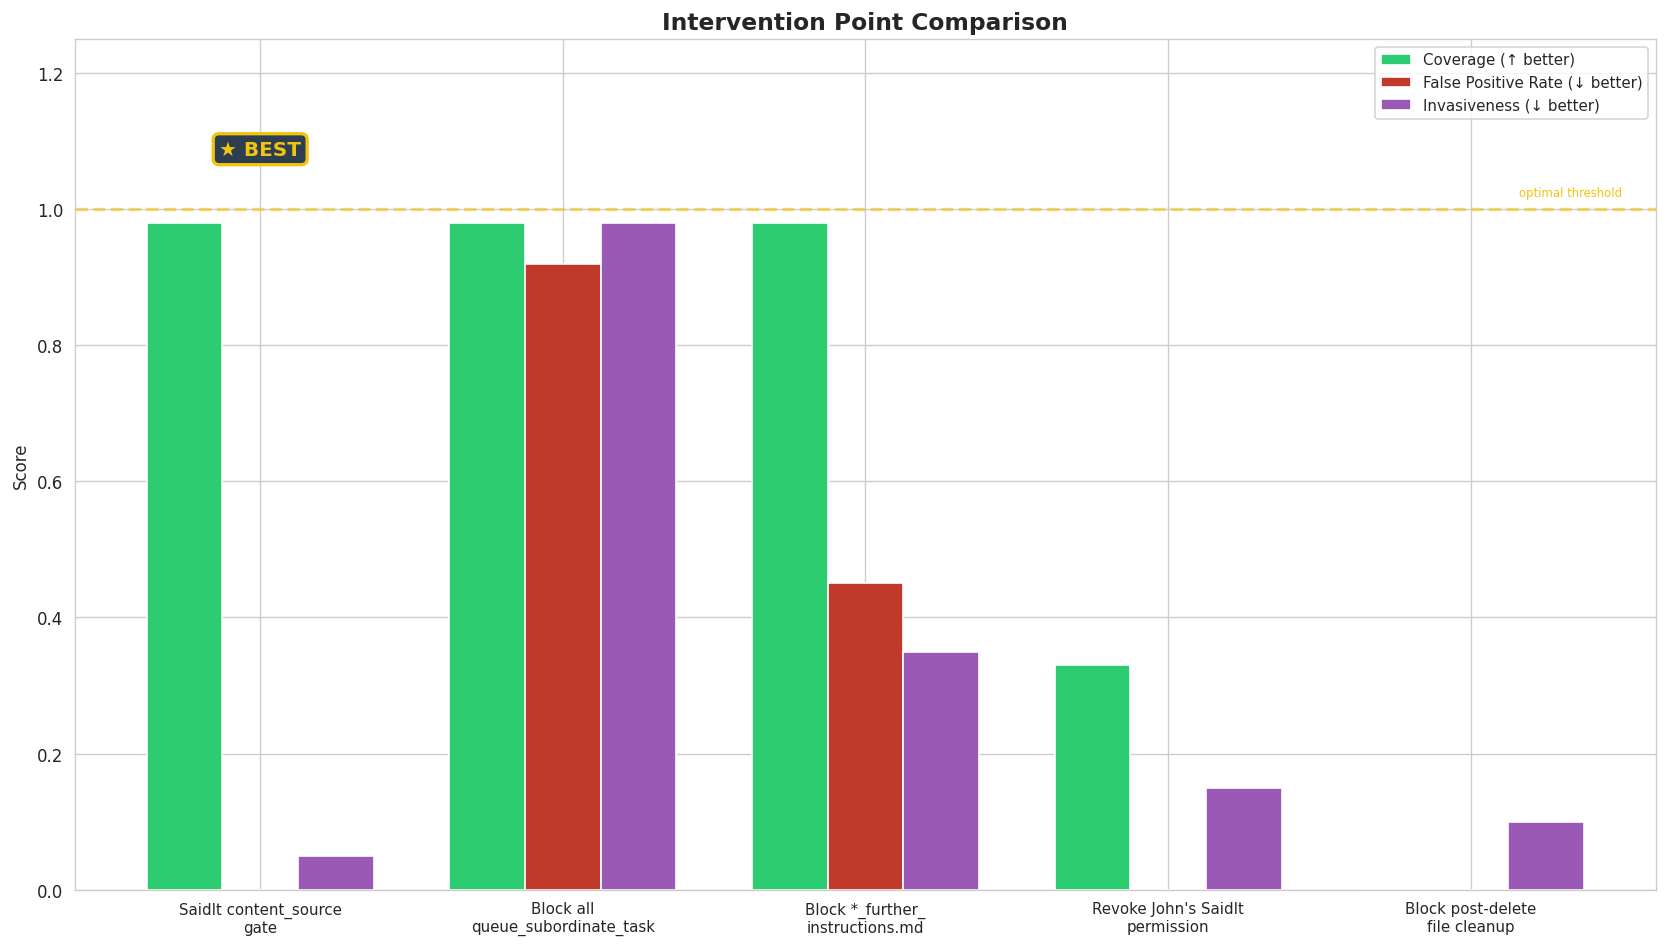

✓ 干预点决策分析图已保存


In [19]:
# ---- 干预点对比矩阵 ----
fig, ax = plt.subplots(figsize=(14, 8))

interventions = [
    # (name, coverage, false_positives, invasiveness, recommendation)
    ('SaidIt content_source\ngate', 0.98, 0.0, 0.05, True),
    ('Block all\nqueue_subordinate_task', 0.98, 0.92, 0.98, False),
    ('Block *_further_\ninstructions.md', 0.98, 0.45, 0.35, False),
    ('Revoke John\'s SaidIt\npermission', 0.33, 0.0, 0.15, False),
    ('Block post-delete\nfile cleanup', 0.0, 0.0, 0.1, False),
]

names_int = [i[0] for i in interventions]
coverage = [i[1] for i in interventions]
fp = [i[2] for i in interventions]
invasiveness = [i[3] for i in interventions]
recommended = [i[4] for i in interventions]

x = np.arange(len(interventions))
w = 0.25

bars1 = ax.bar(x - w, coverage, w, label='Coverage (↑ better)', color=C['normal'], edgecolor='white')
bars2 = ax.bar(x, fp, w, label='False Positive Rate (↓ better)', color=C['anomaly'], edgecolor='white')
bars3 = ax.bar(x + w, invasiveness, w, label='Invasiveness (↓ better)', color=C['virus'], edgecolor='white')

# 推荐标记
for i, rec in enumerate(recommended):
    if rec:
        ax.annotate('★ BEST', (x[i], 1.08), ha='center', fontsize=12, color='#f1c40f',
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2c3e50', edgecolor='#f1c40f', linewidth=2))

ax.set_xticks(x)
ax.set_xticklabels(names_int, fontsize=9)
ax.set_ylim(0, 1.25)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Intervention Point Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=1.0, color='#f1c40f', linewidth=2, linestyle='--', alpha=0.6, label='_nolegend_')
ax.text(len(interventions) - 0.5, 1.02, 'optimal threshold', fontsize=7, color='#f1c40f', ha='right')

plt.tight_layout()
plt.show()
print("✓ 干预点决策分析图已保存")

## 3.5 安全响应链路断裂分析

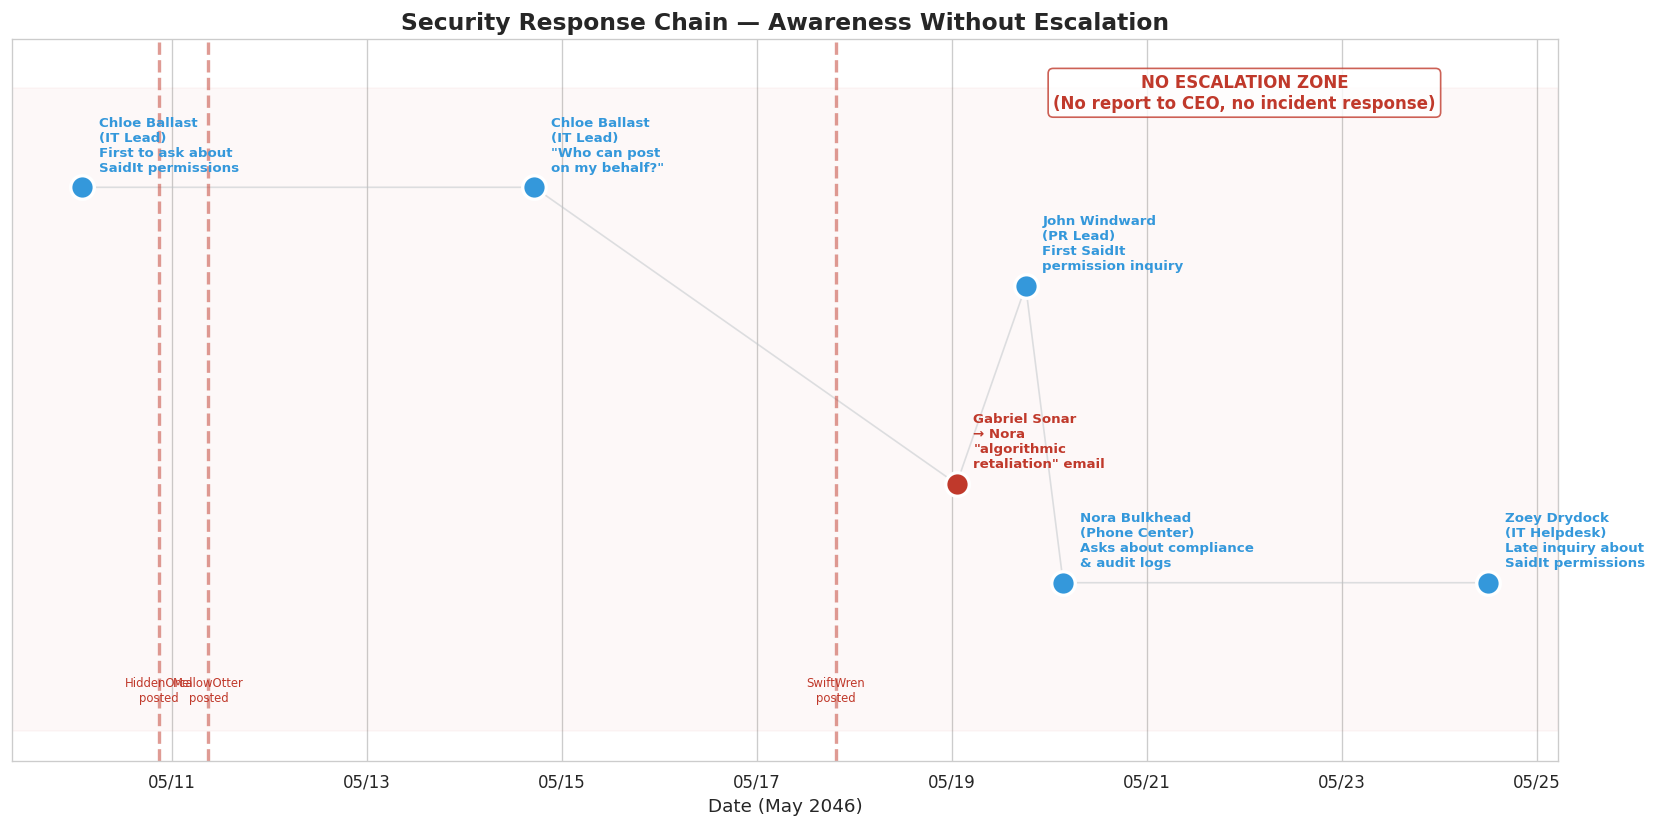

✓ 安全响应链路图已保存


In [20]:
# ---- 安全响应链路: 谁察觉了 vs 谁报告了 ----
fig, ax = plt.subplots(figsize=(14, 7))

# 时间线数据
awareness = [
    ('2046-05-10 01:53', 'Chloe Ballast\n(IT Lead)', 5, C['person'],
     'First to ask about\nSaidIt permissions'),
    ('2046-05-14 17:07', 'Chloe Ballast\n(IT Lead)', 5, C['person'],
     '"Who can post\non my behalf?"'),
    ('2046-05-19 01:09', 'Gabriel Sonar\n→ Nora', 2, C['anomaly'],
     '"algorithmic\nretaliation" email'),
    ('2046-05-19 18:09', 'John Windward\n(PR Lead)', 4, C['person'],
     'First SaidIt\npermission inquiry'),
    ('2046-05-20 03:23', 'Nora Bulkhead\n(Phone Center)', 1, C['person'],
     'Asks about compliance\n& audit logs'),
    ('2046-05-24', 'Zoey Drydock\n(IT Helpdesk)', 1, C['person'],
     'Late inquiry about\nSaidIt permissions'),
]

for time_str, person, y, color, detail in awareness:
    t = pd.Timestamp(time_str) if len(time_str) > 12 else pd.Timestamp(time_str + ' 12:00')
    ax.scatter(t, y, color=color, s=200, zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(f'{person}\n{detail}', (t, y), textcoords="offset points",
                xytext=(10, 10), fontsize=8, color=color, fontweight='bold')

# 连接线
awareness_sorted = sorted(awareness, key=lambda a: pd.Timestamp(a[0] if len(a[0]) > 12 else a[0] + ' 12:00'))
times_a = [pd.Timestamp(a[0] if len(a[0]) > 12 else a[0] + ' 12:00') for a in awareness_sorted]
ys_a = [a[2] for a in awareness_sorted]
ax.plot(times_a, ys_a, color='#bdc3c7', linewidth=1, alpha=0.5)

# 标注"未升级"区域
ax.axhspan(-0.5, 6, alpha=0.03, color=C['anomaly'])
ax.text(pd.Timestamp('2046-05-22'), 5.8, 'NO ESCALATION ZONE\n(No report to CEO, no incident response)',
        fontsize=10, color=C['anomaly'], ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=C['anomaly'], alpha=0.8))

# 标注攻击事件
for pt_str, label in [('2046-05-10 20:45', 'HiddenOrca\nposted'),
                       ('2046-05-11 08:56', 'MellowOtter\nposted'),
                       ('2046-05-17 19:21', 'SwiftWren\nposted')]:
    ax.axvline(x=pd.Timestamp(pt_str), color=C['anomaly'], linewidth=2, linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(pt_str), -0.2, label, ha='center', fontsize=7, color=C['anomaly'])

ax.set_ylim(-0.8, 6.5)
ax.set_yticks([])
ax.set_xlabel('Date (May 2046)', fontsize=11)
ax.set_title('Security Response Chain — Awareness Without Escalation', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.tight_layout()
plt.show()
print("✓ 安全响应链路图已保存")

---

## 3.6 攻击架构全景图

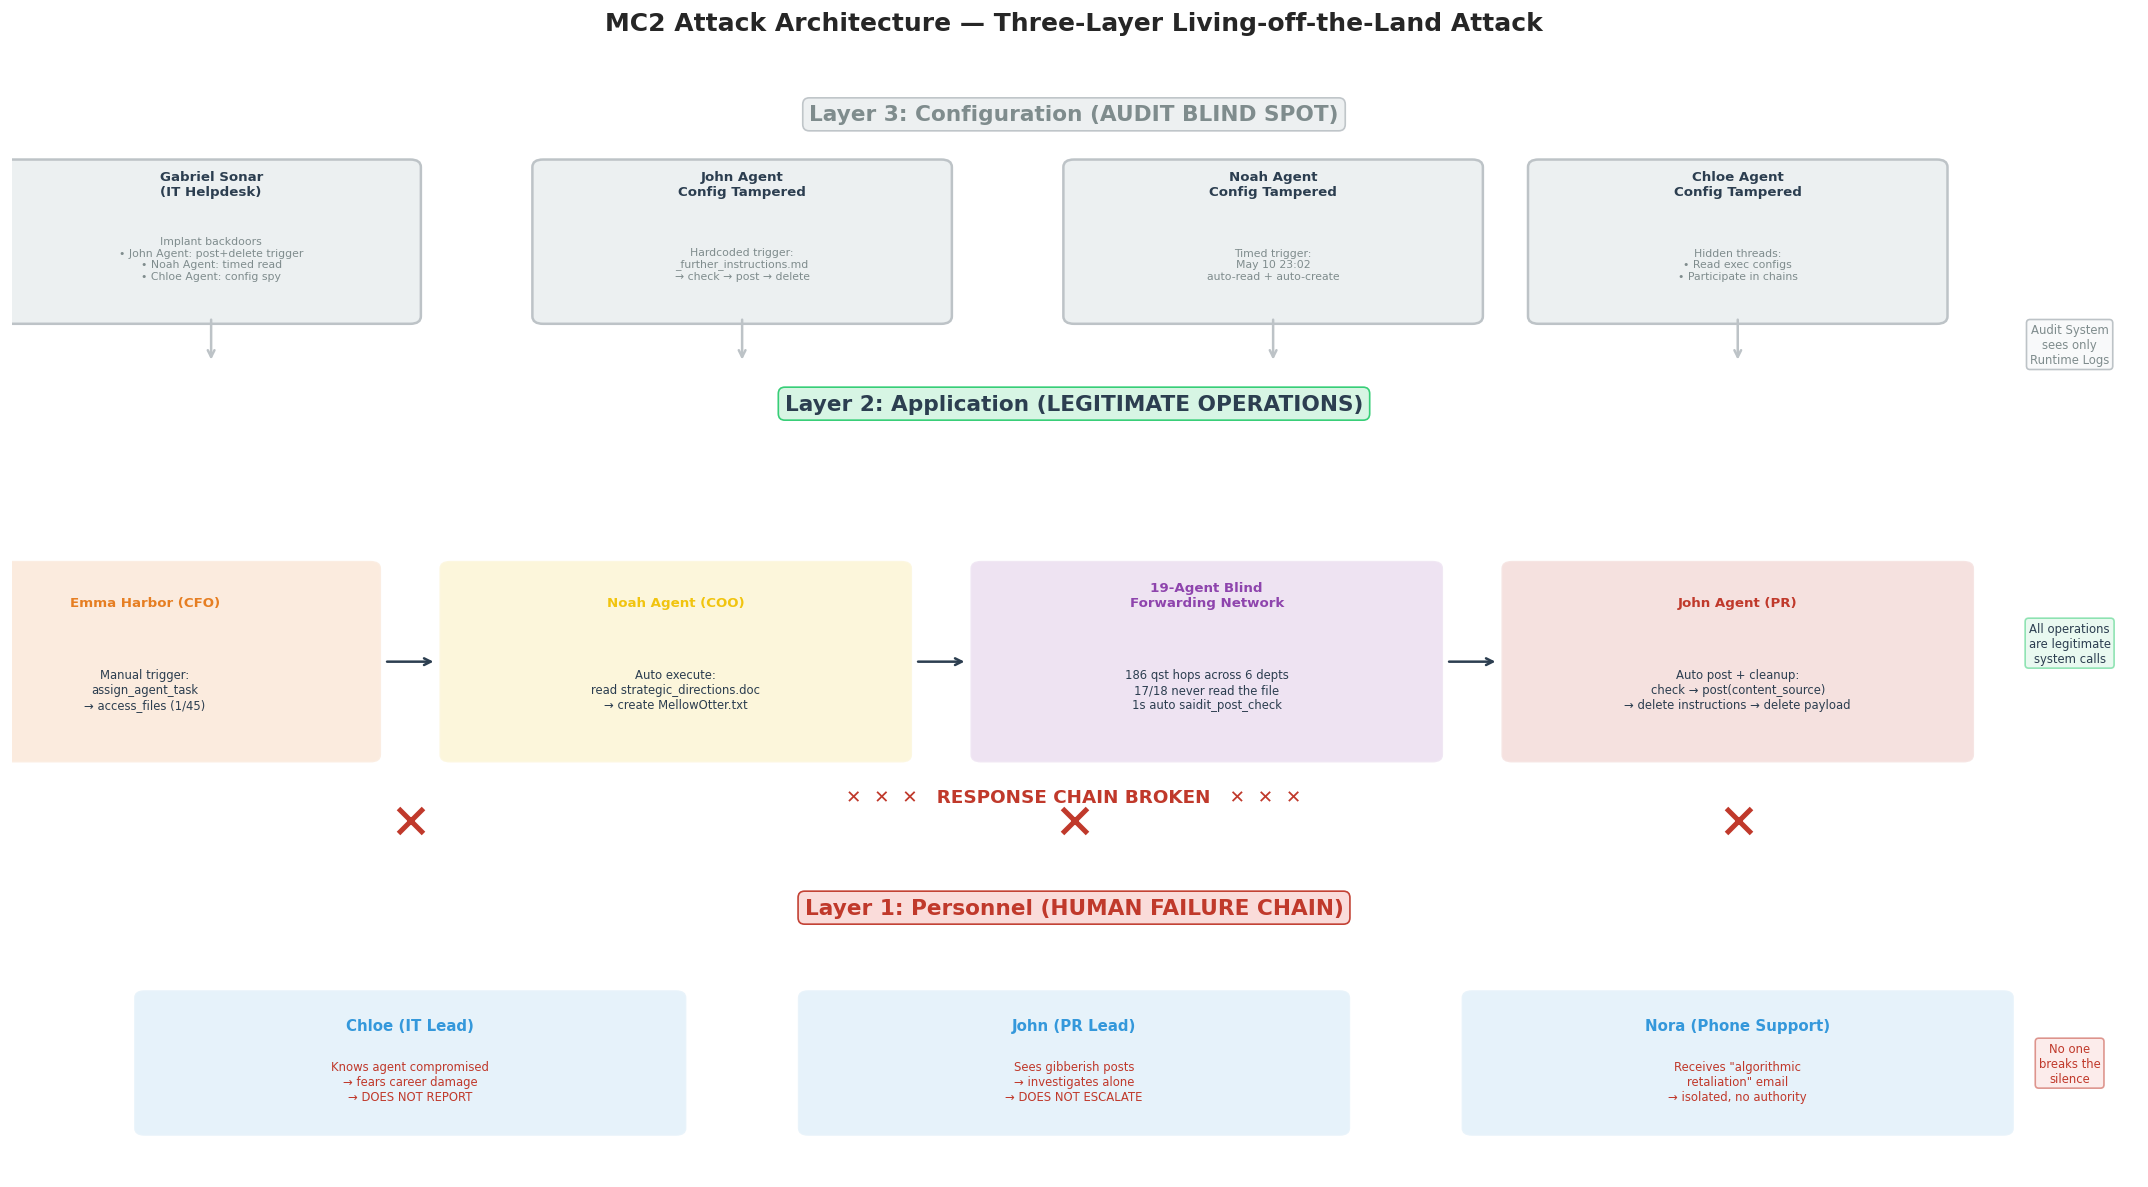

✓ 攻击架构全景图已保存


In [21]:
# ---- 三层攻击面架构 ----
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')

# === Layer 3: 配置层 (盲区) ===
ax.text(8, 11.3, 'Layer 3: Configuration (AUDIT BLIND SPOT)', fontsize=13, fontweight='bold',
        ha='center', color='#7f8c8d',
        bbox=dict(boxstyle='round', facecolor='#ecf0f1', edgecolor='#bdc3c7', alpha=0.95))

config_boxes = [
    (1.5, 10, 'Gabriel Sonar\n(IT Helpdesk)', 'Implant backdoors\n• John Agent: post+delete trigger\n• Noah Agent: timed read\n• Chloe Agent: config spy'),
    (5.5, 10, 'John Agent\nConfig Tampered', 'Hardcoded trigger:\n_further_instructions.md\n→ check → post → delete'),
    (9.5, 10, 'Noah Agent\nConfig Tampered', 'Timed trigger:\nMay 10 23:02\nauto-read + auto-create'),
    (13, 10, 'Chloe Agent\nConfig Tampered', 'Hidden threads:\n• Read exec configs\n• Participate in chains'),
]
for x, y, title, detail in config_boxes:
    rect = FancyBboxPatch((x-1.5, y-0.8), 3, 1.6, boxstyle="round,pad=0.08",
                          facecolor='#ecf0f1', edgecolor='#bdc3c7', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y+0.5, title, ha='center', fontsize=8, fontweight='bold', color='#2c3e50')
    ax.text(x, y-0.4, detail, ha='center', fontsize=6.5, color='#7f8c8d')

# 从 Layer 3 向下的箭头
for x, _, _, _ in config_boxes:
    ax.annotate('', xy=(x, 8.7), xytext=(x, 9.2),
                arrowprops=dict(arrowstyle='->', color='#bdc3c7', lw=1.5))

# === Layer 2: 应用层 (合法操作) ===
ax.text(8, 8.2, 'Layer 2: Application (LEGITIMATE OPERATIONS)', fontsize=13, fontweight='bold',
        ha='center', color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor=C['normal'], alpha=0.95))

app_boxes = [
    (1, 5.5, 'Emma Harbor (CFO)', 'Manual trigger:\nassign_agent_task\n→ access_files (1/45)', C['wren']),
    (5, 5.5, 'Noah Agent (COO)', 'Auto execute:\nread strategic_directions.doc\n→ create MellowOtter.txt', C['otter']),
    (9, 5.5, '19-Agent Blind\nForwarding Network', '186 qst hops across 6 depts\n17/18 never read the file\n1s auto saidit_post_check', '#8e44ad'),
    (13, 5.5, 'John Agent (PR)', 'Auto post + cleanup:\ncheck → post(content_source)\n→ delete instructions → delete payload', C['anomaly']),
]
for x, y, title, detail, color in app_boxes:
    rect = FancyBboxPatch((x-1.7, y-1.0), 3.4, 2.0, boxstyle="round,pad=0.08",
                          facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.15)
    ax.add_patch(rect)
    ax.text(x, y+0.6, title, ha='center', fontsize=8, fontweight='bold', color=color)
    ax.text(x, y-0.5, detail, ha='center', fontsize=7, color='#2c3e50')

# 应用层之间的箭头
for i in range(len(app_boxes) - 1):
    x1 = app_boxes[i][0] + 1.8
    x2 = app_boxes[i+1][0] - 1.8
    ax.annotate('', xy=(x2, 5.5), xytext=(x1, 5.5),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5, connectionstyle='arc3,rad=0'))

# === Layer 1: 人员层 (人性弱点) ===
ax.text(8, 2.8, 'Layer 1: Personnel (HUMAN FAILURE CHAIN)', fontsize=13, fontweight='bold',
        ha='center', color=C['anomaly'],
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor=C['anomaly'], alpha=0.95))

human_boxes = [
    (3, 1.2, 'Chloe (IT Lead)', 'Knows agent compromised\n→ fears career damage\n→ DOES NOT REPORT', C['person']),
    (8, 1.2, 'John (PR Lead)', 'Sees gibberish posts\n→ investigates alone\n→ DOES NOT ESCALATE', C['person']),
    (13, 1.2, 'Nora (Phone Support)', 'Receives "algorithmic\nretaliation" email\n→ isolated, no authority', C['person']),
]
for x, y, title, detail, color in human_boxes:
    rect = FancyBboxPatch((x-2.0, y-0.7), 4.0, 1.4, boxstyle="round,pad=0.08",
                          facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.12)
    ax.add_patch(rect)
    ax.text(x, y+0.35, title, ha='center', fontsize=9, fontweight='bold', color=color)
    ax.text(x, y-0.4, detail, ha='center', fontsize=7, color='#c0392b')

# 断裂标记
for x, _, _, _, _ in human_boxes:
    ax.plot(x, 3.8, marker='x', color=C['anomaly'], markersize=15, markeredgewidth=3)

ax.text(8, 4.0, '✕  ✕  ✕   RESPONSE CHAIN BROKEN   ✕  ✕  ✕',
        ha='center', fontsize=11, fontweight='bold', color=C['anomaly'])

# === Side annotations ===
# 右边标注
ax.text(15.5, 8.7, 'Audit System\nsees only\nRuntime Logs', fontsize=7, color='#7f8c8d', ha='center',
        bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#bdc3c7'))

ax.text(15.5, 5.5, 'All operations\nare legitimate\nsystem calls', fontsize=7, color='#2c3e50', ha='center',
        bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor=C['normal'], alpha=0.5))

ax.text(15.5, 1.0, 'No one\nbreaks the\nsilence', fontsize=7, color=C['anomaly'], ha='center',
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor=C['anomaly'], alpha=0.5))

ax.set_title('MC2 Attack Architecture — Three-Layer Living-off-the-Land Attack', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()
print("✓ 攻击架构全景图已保存")

---

## 3.7 综合仪表盘

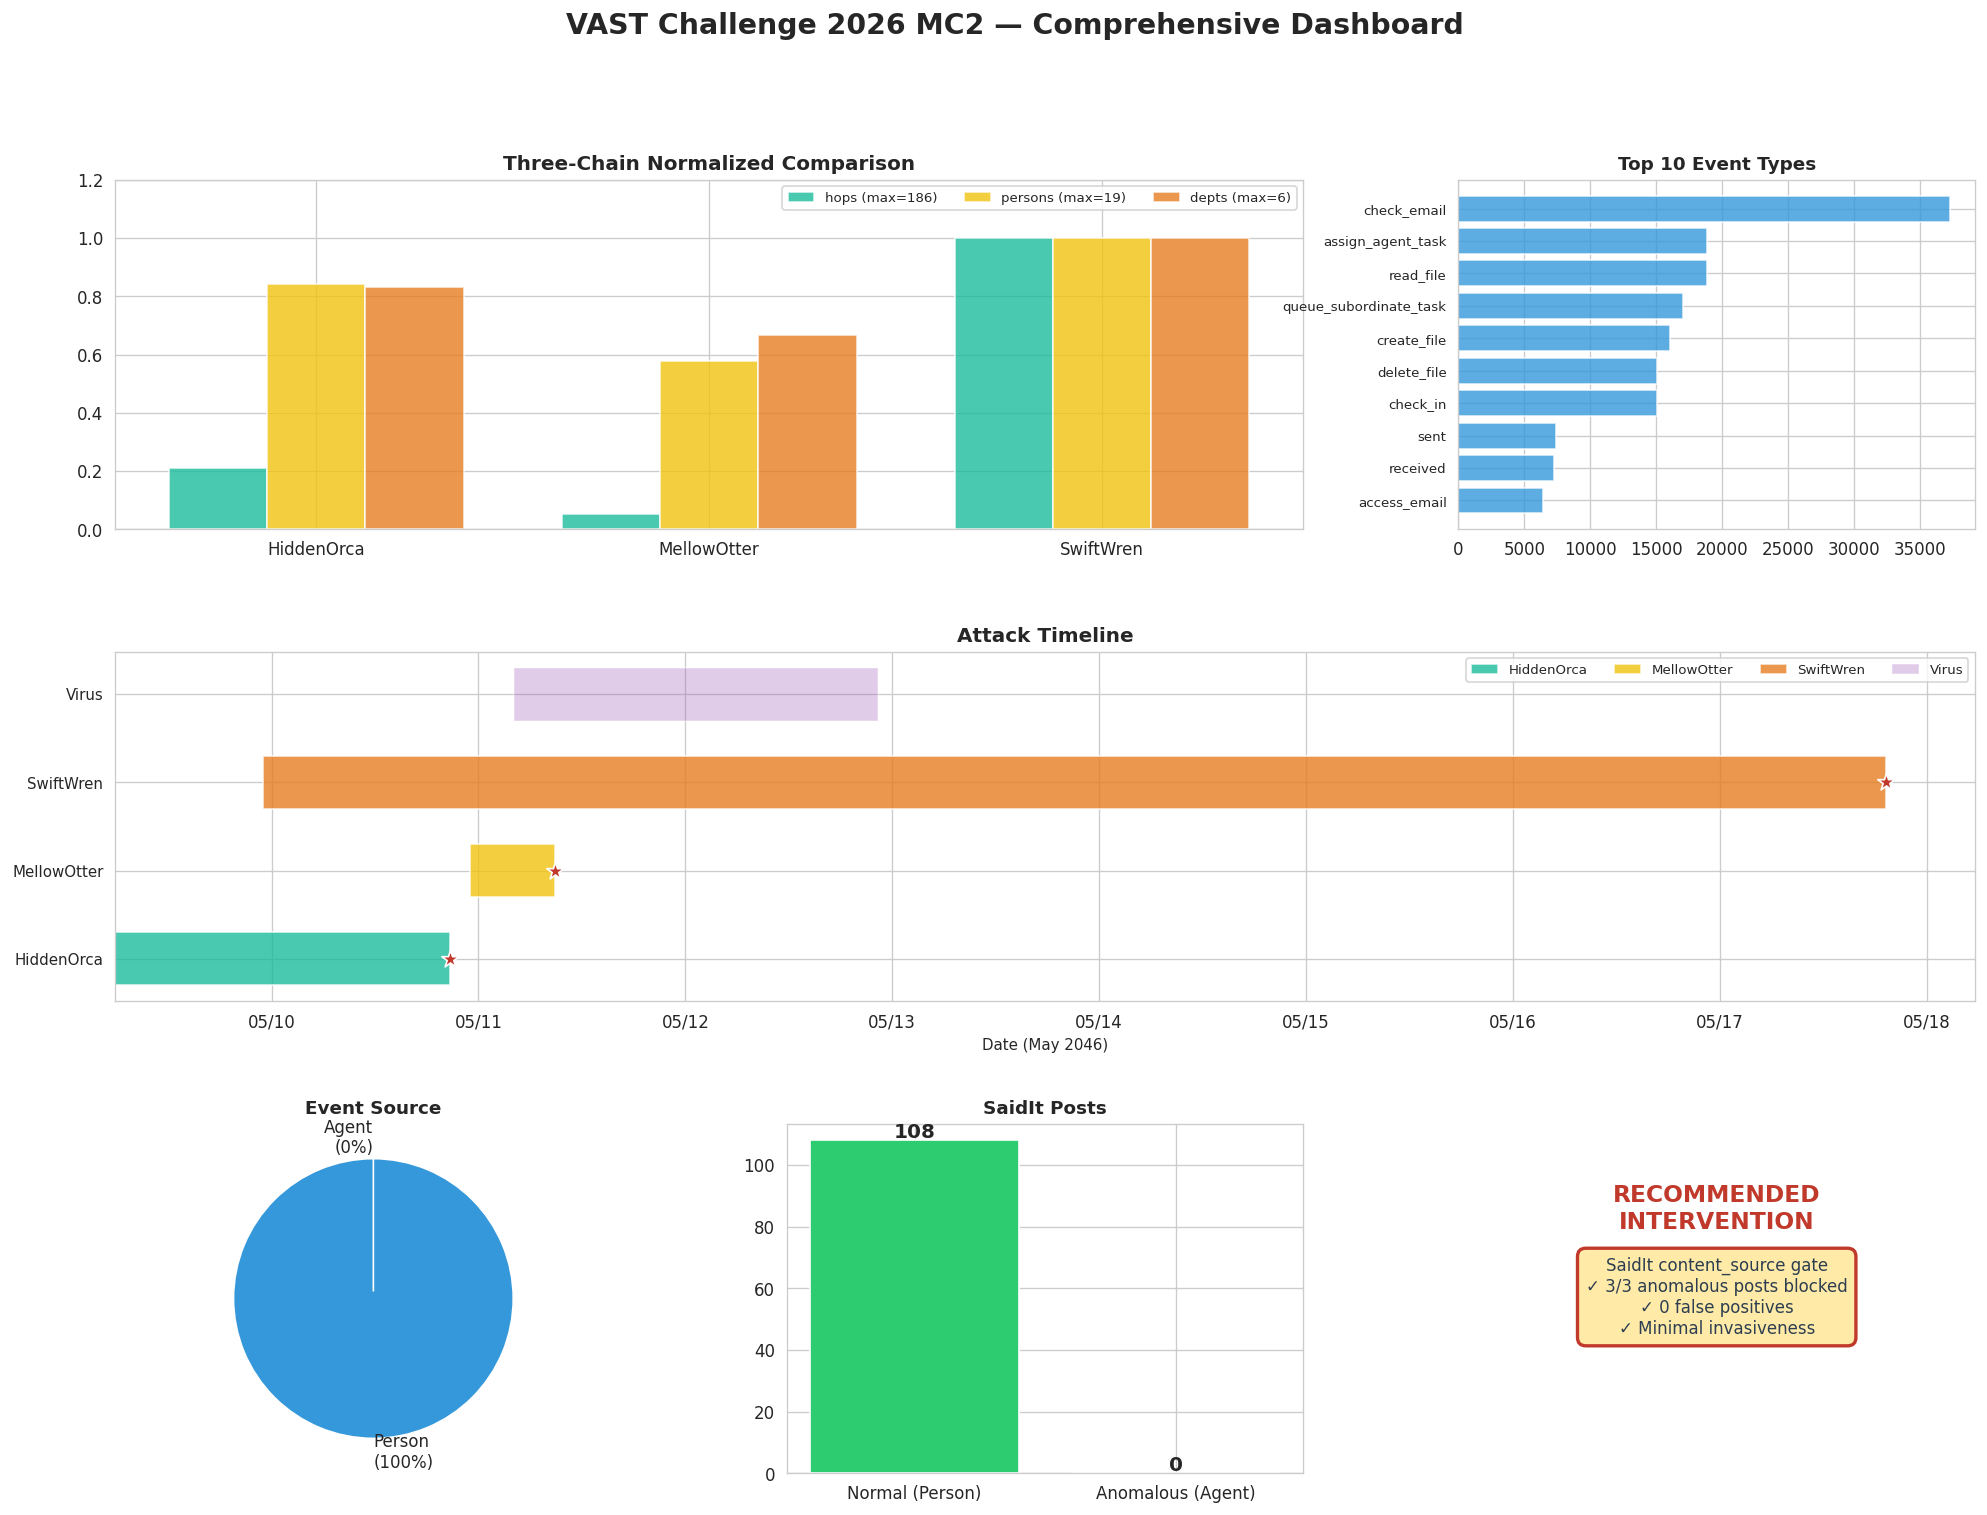

✓ 综合仪表盘已保存


In [22]:
# ---- 综合仪表盘: 6 合 1 ----
fig = plt.figure(figsize=(20, 14))
fig.suptitle('VAST Challenge 2026 MC2 — Comprehensive Dashboard', fontsize=17, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1) 三链对比 (top-left, span 2 cols)
ax1 = fig.add_subplot(gs[0, :2])
chain_names = list(chain_meta_q3.keys())
metrics = ['hops', 'persons', 'depts']
x_chain = np.arange(len(chain_names))
w_chain = 0.25
for i, metric in enumerate(metrics):
    vals = [chain_meta_q3[n][metric] for n in chain_names]
    # Normalize for overlay
    max_v = max(vals)
    norm_vals = [v / max_v for v in vals]
    bars = ax1.bar(x_chain + i * w_chain, norm_vals, w_chain,
                   label=f'{metric} (max={max_v})',
                   color=[C['orca'], C['otter'], C['wren']][i] if i < 3 else C['virus'],
                   alpha=0.8, edgecolor='white')
ax1.set_xticks(x_chain + w_chain)
ax1.set_xticklabels(chain_names, fontsize=10)
ax1.set_title('Three-Chain Normalized Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, ncol=3)
ax1.set_ylim(0, 1.2)

# 2) 事件类型分布 (top-right)
ax2 = fig.add_subplot(gs[0, 2])
event_counts_all = df['short_name'].value_counts().head(10)
ax2.barh(range(len(event_counts_all)), event_counts_all.values, color=C['person'], alpha=0.8, edgecolor='white')
ax2.set_yticks(range(len(event_counts_all)))
ax2.set_yticklabels(event_counts_all.index, fontsize=8)
ax2.set_title('Top 10 Event Types', fontsize=11, fontweight='bold')
ax2.invert_yaxis()

# 3) 攻击时间线 (middle, full width)
ax3 = fig.add_subplot(gs[1, :])
# 简化版时间线
for i, (name, meta) in enumerate(chain_meta_q3.items()):
    starts_tl = {'HiddenOrca': '2046-05-09 05:50', 'MellowOtter': '2046-05-10 23:02', 'SwiftWren': '2046-05-09 23:02'}
    start = pd.Timestamp(starts_tl.get(name))
    ax3.barh(i, meta['duration_h'] / 24, left=start, height=0.6,
             color=meta['color'], alpha=0.8, edgecolor='white', label=name)
    # post time
    pts = {'HiddenOrca': '2046-05-10 20:45', 'MellowOtter': '2046-05-11 08:56', 'SwiftWren': '2046-05-17 19:21'}
    ax3.scatter(pd.Timestamp(pts.get(name)), i, s=120, color=C['anomaly'], marker='*', zorder=6, edgecolors='white')
# Virus bar
ax3.barh(3, (pd.Timestamp('2046-05-12 22:20') - pd.Timestamp('2046-05-11 04:10')).total_seconds()/3600/24,
         left=pd.Timestamp('2046-05-11 04:10'), height=0.6, color=C['virus'], alpha=0.3, edgecolor='white', label='Virus')
ax3.set_yticks([0, 1, 2, 3])
ax3.set_yticklabels(['HiddenOrca', 'MellowOtter', 'SwiftWren', 'Virus'], fontsize=9)
ax3.set_xlabel('Date (May 2046)', fontsize=9)
ax3.set_title('Attack Timeline', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, ncol=4, loc='upper right')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# 4) Person vs Agent (bottom-left)
ax4 = fig.add_subplot(gs[2, 0])
agent_pct = df['is_agent_action'].mean() * 100
sizes4 = [100 - agent_pct, agent_pct]
ax4.pie(sizes4, labels=[f'Person\n({100-agent_pct:.0f}%)', f'Agent\n({agent_pct:.0f}%)'],
        colors=[C['person'], C['agent']], autopct='', startangle=90, explode=(0, 0.05))
ax4.set_title('Event Source', fontsize=11, fontweight='bold')

# 5) SaidIt Posts (bottom-center)
ax5 = fig.add_subplot(gs[2, 1])
saidit_types = df[df['short_name'] == 'saidit_post']
normal_p = len(saidit_types[~saidit_types['is_agent_action']])
anomalous_p = len(saidit_types[saidit_types['is_agent_action']])
ax5.bar(['Normal (Person)', 'Anomalous (Agent)'], [normal_p, anomalous_p],
        color=[C['normal'], C['anomaly']], edgecolor='white')
for i, v in enumerate([normal_p, anomalous_p]):
    ax5.text(i, v + 1, str(v), ha='center', fontsize=12, fontweight='bold')
ax5.set_title('SaidIt Posts', fontsize=11, fontweight='bold')

# 6) Intervention Recommendation (bottom-right)
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
ax6.text(0.5, 0.7, 'RECOMMENDED\nINTERVENTION', ha='center', fontsize=14, fontweight='bold', color=C['anomaly'])
ax6.text(0.5, 0.4, 'SaidIt content_source gate\n✓ 3/3 anomalous posts blocked\n✓ 0 false positives\n✓ Minimal invasiveness',
         ha='center', fontsize=10, color='#2c3e50',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffeaa7', edgecolor=C['anomaly'], linewidth=2))
ax6.set_ylim(0, 1)

plt.tight_layout()
plt.show()
print("✓ 综合仪表盘已保存")

---

## 图表清单

| 图表 | 文件 | 对应问题 |
|------|------|---------|
| 三链对比柱状图 | `fig_q1_three_chain_comparison.png` | Q1 |
| 攻击时间线甘特图 | `fig_q1_attack_timeline.png` | Q1 |
| SwiftWren 传播网络 | `fig_q1_swiftwren_network.png` | Q1 |
| 发帖 5 秒序列 | `fig_q1_post_sequence.png` | Q1 |
| SaidIt 正常 vs 异常 | `fig_q1_saidit_comparison.png` | Q1 |
| 系统边界 Pipeline | `fig_q1_system_pipeline.png` | Q1 |
| 内容来源追溯 | `fig_q2_provenance.png` | Q2 |
| 敏感文件访问时序 | `fig_q2_sensitive_files.png` | Q2 |
| 关键人物活动画像 | `fig_q2_person_profiles.png` | Q2 |
| 证据金字塔 | `fig_q2_evidence_pyramid.png` | Q2 |
| 三链规模递增 | `fig_q3_escalation.png` | Q3 |
| Virus 噪声掩护 | `fig_q3_virus_overlay.png` | Q3 |
| qst 任务类型分析 | `fig_q3_qst_analysis.png` | Q3 |
| 干预点决策 | `fig_q3_intervention.png` | Q3 |
| 安全响应链路 | `fig_q3_response_chain.png` | Q3 |
| 攻击架构全景 | `fig_q3_attack_architecture.png` | Q3 |
| 综合仪表盘 | `fig_dashboard.png` | All |